##  CELL 1 — Install Semua Library yang Dibutuhkan

In [ ]:
print('Installing libraries... harap tunggu...')

import subprocess
packages = [
    'transformers==4.40.0',
    'timm',
    'pycocotools',
    'seaborn',
    'scikit-learn'
]
for pkg in packages:
    subprocess.run(['pip', 'install', '-q', pkg], check=True)
    print(f'  ✅ {pkg}')

print('\n🎉 Semua library berhasil diinstall!')

Installing libraries... harap tunggu...
  ✅ transformers==4.40.0
  ✅ timm
  ✅ pycocotools
  ✅ seaborn
  ✅ scikit-learn

🎉 Semua library berhasil diinstall!


##  CELL 2 — Mount Google Drive

In [ ]:
from google.colab import drive
import os


if not os.path.exists('/content/drive/MyDrive'):
    print('Menghubungkan ke Google Drive...')

    drive.mount('/content/drive', force_remount=True)
else:
    print('✅ Google Drive SUDAH terhubung sebelumnya!')

# Melanjutkan proses Anda
print('\nIsi folder MyDrive:')
try:
    print(os.listdir('/content/drive/MyDrive'))
except Exception as e:
    print(f"Gagal membaca isi folder: {e}")

Menghubungkan ke Google Drive...
Mounted at /content/drive

Isi folder MyDrive:
['Classroom', 'Biologi perlakuan pada kentang (1).docx', 'FLUIDA STATIS DINAMIS - CORONA Vincent Wijaya XI IPA (1).docx', 'Tugas bahasa indonesia teks eksplanasi (Banjir) Vincent W. XI IPA.docx', '201613.jpg', '201614.jpg', '201612.jpg', '204311.jpg', '214787.jpg', '214786.jpg', '221120.jpg', '221886.jpg', 'Cerpen Vincent W..docx', '227536.jpg', 'Teks ceramah Vincent Wijaya.pdf', 'Teks ceramah Vincent Wijaya (1).gdoc', 'Teks ceramah Vincent Wijaya.gdoc', 'Vincent Wijaya - Song Practice.gdoc', '239279.jpg', '239280.jpg', '239281.jpg', 'Tugas Mengidentifikasi Isi & bentuk penyampaian Ceramah yang Telah ditonton.docx', '243359.jpg', '243480.jpg', '243478.jpg', '243479.jpg', '250702.jpg', '251552.jpg', '251556.jpg', '251555.jpg', '251554.jpg', '251553.jpg', '253453.jpg', '253452.jpg', '253451.jpg', '253900.jpg', '253901.jpg', '254103.jpg', '254104.jpg', '257316 (1).jpg', 'IMG_20201122_172329.jpg', 'IMG_20201122

##  CELL 3 — Konfigurasi Path Dataset


In [ ]:
import os

# ================================================================
# ⚠️ EDIT BAGIAN INI SESUAI NAMA FOLDER OUTPUT KAMU
# Tambah atau kurangi nama folder sesuai jumlah kelas yang ada
# ================================================================
BASE_DATASET = '/content/drive/MyDrive/data_latih_2_70_20_10'

OUTPUT_FOLDERS = [
    'output_almond',
    'output_mete',
    'output_kerang',
    'output_kepiting',
    'output_telur',
    'output_ikan',
    'output_mie',
    'output_tahu',
    'output_tempe',
    'output_udang',
    # Tambahkan folder lain jika ada, contoh:
    # 'output_ikan',
    # 'output_telur',
]
# ================================================================

# ----------------------------------------------------------------
# Path otomatis per folder output
# ----------------------------------------------------------------
# Kumpulkan semua path train, val, test dari setiap folder output
all_train_img_dirs  = []
all_train_ann_files = []
all_val_img_dirs    = []
all_val_ann_files   = []
all_test_img_dirs   = []
all_test_ann_files  = []

for folder in OUTPUT_FOLDERS:
    base = os.path.join(BASE_DATASET, folder)
    all_train_img_dirs .append(os.path.join(base, 'train', 'images'))
    all_train_ann_files.append(os.path.join(base, 'train', 'annotations', 'instances_train_aug.json'))
    all_val_img_dirs   .append(os.path.join(base, 'valid',       'images'))
    all_val_ann_files  .append(os.path.join(base, 'valid',       'annotations', 'instances_valid.json'))
    all_test_img_dirs  .append(os.path.join(base, 'test',      'images'))
    all_test_ann_files .append(os.path.join(base, 'test',      'annotations', 'instances_test.json'))

# ----------------------------------------------------------------
# Verifikasi semua path
# ----------------------------------------------------------------
print('Mengecek path dataset...')
print('='*60)
all_ok = True

for i, folder in enumerate(OUTPUT_FOLDERS):
    print(f'\n  📁 {folder}')
    checks = [
        (all_train_img_dirs[i],   'Train Images folder'),
        (all_train_ann_files[i],  'Train JSON (instances_train_mix.json)'),
        (all_val_img_dirs[i],     'Val Images folder'),
        (all_val_ann_files[i],    'Val JSON'),
        (all_test_img_dirs[i],    'Test Images folder'),
        (all_test_ann_files[i],   'Test JSON'),
    ]
    for path, nama in checks:
        exists = os.path.exists(path)
        status = '  ✅' if exists else '  ❌ TIDAK DITEMUKAN'
        print(f'    {status}  {nama}')
        print(f'           {path}')
        if not exists:
            all_ok = False

print('\n' + '='*60)
if all_ok:
    print('✅ Semua path valid! Lanjut ke cell berikutnya.')
else:
    print('❌ Ada path yang tidak ditemukan!')
    print('   Pastikan nama folder di OUTPUT_FOLDERS sudah benar.')

Mengecek path dataset...

  📁 output_almond
      ✅  Train Images folder
           /content/drive/MyDrive/data_latih_2_70_20_10/output_almond/train/images
      ✅  Train JSON (instances_train_mix.json)
           /content/drive/MyDrive/data_latih_2_70_20_10/output_almond/train/annotations/instances_train_aug.json
      ✅  Val Images folder
           /content/drive/MyDrive/data_latih_2_70_20_10/output_almond/valid/images
      ✅  Val JSON
           /content/drive/MyDrive/data_latih_2_70_20_10/output_almond/valid/annotations/instances_valid.json
      ✅  Test Images folder
           /content/drive/MyDrive/data_latih_2_70_20_10/output_almond/test/images
      ✅  Test JSON
           /content/drive/MyDrive/data_latih_2_70_20_10/output_almond/test/annotations/instances_test.json

  📁 output_mete
      ✅  Train Images folder
           /content/drive/MyDrive/data_latih_2_70_20_10/output_mete/train/images
      ✅  Train JSON (instances_train_mix.json)
           /content/drive/MyDrive/dat

In [ ]:
import json
import os
from collections import defaultdict

# ================================================================
# CEK STATUS ANOTASI SELURUH DATASET
# ================================================================

def cek_anotasi(ann_file, img_dir, nama_split):
    """
    Mengecek gambar mana yang sudah & belum punya anotasi bbox.
    """
    with open(ann_file, 'r') as f:
        coco = json.load(f)

    # Kumpulkan image_id yang punya anotasi
    img_ids_punya_ann = set()
    ann_count_per_img = defaultdict(int)

    for ann in coco['annotations']:
        img_ids_punya_ann.add(ann['image_id'])
        ann_count_per_img[ann['image_id']] += 1

    # Pisahkan gambar yang sudah & belum punya anotasi
    sudah_anotasi  = []
    belum_anotasi  = []

    for img in coco['images']:
        img_path = os.path.join(img_dir, img['file_name'])
        file_ada = os.path.exists(img_path)

        info = {
            'id'           : img['id'],
            'file_name'    : img['file_name'],
            'file_ada'     : file_ada,
            'jumlah_bbox'  : ann_count_per_img.get(img['id'], 0)
        }

        if img['id'] in img_ids_punya_ann:
            sudah_anotasi.append(info)
        else:
            belum_anotasi.append(info)

    # ----------------------------------------------------------------
    # Print Ringkasan
    # ----------------------------------------------------------------
    print(f'\n{"="*60}')
    print(f'  SPLIT: {nama_split.upper()}')
    print(f'{"="*60}')
    print(f'  Total gambar          : {len(coco["images"])}')
    print(f'  Total anotasi         : {len(coco["annotations"])}')
    print(f'  ✅ Sudah ada bbox     : {len(sudah_anotasi)} gambar')
    print(f'  ❌ Belum ada bbox     : {len(belum_anotasi)} gambar')

    # Statistik jumlah bbox per gambar
    if sudah_anotasi:
        jumlah_bbox_list = [img['jumlah_bbox'] for img in sudah_anotasi]
        print(f'\n  --- Statistik Bbox per Gambar ---')
        print(f'  Min bbox  : {min(jumlah_bbox_list)}')
        print(f'  Max bbox  : {max(jumlah_bbox_list)}')
        print(f'  Rata-rata : {sum(jumlah_bbox_list)/len(jumlah_bbox_list):.2f}')

    # ----------------------------------------------------------------
    # Print daftar gambar BELUM anotasi
    # ----------------------------------------------------------------
    if belum_anotasi:
        print(f'\n  ❌ DAFTAR GAMBAR BELUM PUNYA ANOTASI BBOX ({len(belum_anotasi)} gambar):')
        print(f'  {"-"*55}')
        for i, img in enumerate(belum_anotasi, 1):
            file_status = '✅ file ada' if img['file_ada'] else '❌ file tidak ada'
            print(f'  {i:>3}. {img["file_name"]:<40} [{file_status}]')
    else:
        print(f'\n  ✅ Semua gambar sudah punya anotasi bbox!')

    # ----------------------------------------------------------------
    # Print daftar gambar SUDAH anotasi (top 10)
    # ----------------------------------------------------------------
    print(f'\n  ✅ DAFTAR GAMBAR SUDAH PUNYA ANOTASI (10 pertama):')
    print(f'  {"-"*55}')
    print(f'  {"No":<4} {"File Name":<38} {"Bbox":>5}')
    print(f'  {"-"*55}')
    for i, img in enumerate(sudah_anotasi[:10], 1):
        print(f'  {i:<4} {img["file_name"]:<38} {img["jumlah_bbox"]:>5} bbox')
    if len(sudah_anotasi) > 10:
        print(f'  ... dan {len(sudah_anotasi) - 10} gambar lainnya')

    return sudah_anotasi, belum_anotasi


# ================================================================
# CEK PER FOLDER OUTPUT (almond, cashew, dll)
# ================================================================
print('MENGECEK STATUS ANOTASI SEMUA DATASET')
print('='*60)

hasil_semua = {}

for folder in OUTPUT_FOLDERS:
    base = os.path.join(BASE_DATASET, folder)
    print(f'\n📁 Folder: {folder}')

    splits = {
        'train_aug': {
            'ann' : os.path.join(base, 'train', 'annotations', 'instances_train_aug.json'),
            'img' : os.path.join(base, 'train', 'images')
        },
        'val': {
            'ann' : os.path.join(base, 'valid', 'annotations', 'instances_valid.json'),
            'img' : os.path.join(base, 'valid', 'images')
        },
        'test': {
            'ann' : os.path.join(base, 'test', 'annotations', 'instances_test.json'),
            'img' : os.path.join(base, 'test', 'images')
        },
    }

    hasil_semua[folder] = {}
    for split_name, paths in splits.items():
        if not os.path.exists(paths['ann']):
            print(f'  ⚠️  {split_name}: file JSON tidak ditemukan, skip.')
            continue
        sudah, belum = cek_anotasi(paths['ann'], paths['img'],
                                    f'{folder} - {split_name}')
        hasil_semua[folder][split_name] = {
            'sudah': len(sudah),
            'belum': len(belum)
        }

# ================================================================
# RINGKASAN AKHIR SEMUA FOLDER
# ================================================================
print('\n\n' + '='*60)
print('  RINGKASAN AKHIR SEMUA FOLDER & SPLIT')
print('='*60)
print(f'  {"Folder":<20} {"Split":<12} {"✅ Sudah":>10} {"❌ Belum":>10}')
print(f'  {"-"*55}')

total_sudah = 0
total_belum = 0

for folder, splits in hasil_semua.items():
    for split_name, counts in splits.items():
        print(f'  {folder:<20} {split_name:<12} '
              f'{counts["sudah"]:>10} {counts["belum"]:>10}')
        total_sudah += counts['sudah']
        total_belum += counts['belum']

print(f'  {"-"*55}')
print(f'  {"TOTAL":<20} {"":<12} {total_sudah:>10} {total_belum:>10}')
print(f'\n  Total seluruh gambar   : {total_sudah + total_belum}')
print(f'  ✅ Sudah dianotasi     : {total_sudah}')
print(f'  ❌ Belum dianotasi     : {total_belum}')

if total_belum == 0:
    print('\n  🎉 Semua gambar sudah punya anotasi bbox!')
else:
    print(f'\n  ⚠️  Ada {total_belum} gambar yang belum punya anotasi!')
    print(f'     Silakan anotasi menggunakan tools seperti:')
    print(f'     - LabelImg  : github.com/heartexlabs/labelImg')
    print(f'     - Roboflow  : roboflow.com')
    print(f'     - CVAT      : cvat.ai')
print('='*60)

MENGECEK STATUS ANOTASI SEMUA DATASET

📁 Folder: output_almond

  SPLIT: OUTPUT_ALMOND - TRAIN_AUG
  Total gambar          : 1120
  Total anotasi         : 47375
  ✅ Sudah ada bbox     : 1120 gambar
  ❌ Belum ada bbox     : 0 gambar

  --- Statistik Bbox per Gambar ---
  Min bbox  : 1
  Max bbox  : 171
  Rata-rata : 42.30

  ✅ Semua gambar sudah punya anotasi bbox!

  ✅ DAFTAR GAMBAR SUDAH PUNYA ANOTASI (10 pertama):
  -------------------------------------------------------
  No   File Name                               Bbox
  -------------------------------------------------------
  1    ori_almond_0002.jpg                       72 bbox
  2    aug01_bright_almond_0002.jpg              72 bbox
  3    aug02_dark_almond_0002.jpg                72 bbox
  4    aug03_fliph_almond_0002.jpg               72 bbox
  5    aug04_flipv_almond_0002.jpg               72 bbox
  6    aug05_rot_left_almond_0002.jpg            84 bbox
  7    aug06_rot_right_almond_0002.jpg           73 bbox
  8    aug07

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import shutil
import time

# ================================================================
# COPY DATASET KE LOKAL COLAB UNTUK MEMPERCEPAT I/O
# Dataset di Drive dibaca ~3-10x lebih lambat dari lokal
# ================================================================

LOCAL_BASE = '/content/dataset_latih_baru_2_70_20_10'  # Folder tujuan di SSD lokal Colab

print('='*60)
print('  MENYALIN DATASET KE LOKAL COLAB')
print('  (Proses ini hanya perlu dilakukan sekali per sesi)')
print('='*60)

t0 = time.time()

for folder in OUTPUT_FOLDERS:
    src_base = os.path.join(BASE_DATASET, folder)
    dst_base = os.path.join(LOCAL_BASE, folder)

    for split, img_subdir, ann_subdir, ann_name in [
        ('train', 'train/images', 'train/annotations', 'instances_train_aug.json'),
        ('valid',     'valid/images',     'valid/annotations',     'instances_valid.json'),
        ('test',      'test/images',      'test/annotations',      'instances_test.json'),
    ]:
        src_img = os.path.join(src_base, img_subdir)
        dst_img = os.path.join(dst_base, img_subdir)
        src_ann = os.path.join(src_base, ann_subdir, ann_name)
        dst_ann_dir = os.path.join(dst_base, ann_subdir)

        # Copy annotations
        os.makedirs(dst_ann_dir, exist_ok=True)
        if os.path.exists(src_ann):
            shutil.copy2(src_ann, os.path.join(dst_ann_dir, ann_name))

        # Copy images
        os.makedirs(dst_img, exist_ok=True)
        if os.path.exists(src_img):
            for fname in os.listdir(src_img):
                src_f = os.path.join(src_img, fname)
                dst_f = os.path.join(dst_img, fname)
                if not os.path.exists(dst_f):  # Skip jika sudah ada
                    shutil.copy2(src_f, dst_f)

    print(f'  ✅ {folder} selesai disalin')

elapsed = time.time() - t0
print(f'\n✅ Semua dataset berhasil disalin ke {LOCAL_BASE}')
print(f'   Waktu salin: {elapsed:.1f} detik')

# ================================================================
# UPDATE PATH KE LOKAL — GANTI semua list path ke lokal
# ================================================================
all_train_img_dirs  = []
all_train_ann_files = []
all_val_img_dirs    = []
all_val_ann_files   = []
all_test_img_dirs   = []
all_test_ann_files  = []

for folder in OUTPUT_FOLDERS:
    base = os.path.join(LOCAL_BASE, folder)
    all_train_img_dirs .append(os.path.join(base, 'train', 'images'))
    all_train_ann_files.append(os.path.join(base, 'train', 'annotations', 'instances_train_aug.json'))
    all_val_img_dirs   .append(os.path.join(base, 'valid',     'images'))
    all_val_ann_files  .append(os.path.join(base, 'valid',     'annotations', 'instances_valid.json'))
    all_test_img_dirs  .append(os.path.join(base, 'test',      'images'))
    all_test_ann_files .append(os.path.join(base, 'test',      'annotations', 'instances_test.json'))

print('\n✅ Semua path di-update ke lokal. Lanjutkan ke Cell 5.')

  MENYALIN DATASET KE LOKAL COLAB
  (Proses ini hanya perlu dilakukan sekali per sesi)
  ✅ output_almond selesai disalin
  ✅ output_mete selesai disalin
  ✅ output_kerang selesai disalin
  ✅ output_kepiting selesai disalin
  ✅ output_telur selesai disalin
  ✅ output_ikan selesai disalin
  ✅ output_mie selesai disalin
  ✅ output_tahu selesai disalin
  ✅ output_tempe selesai disalin
  ✅ output_udang selesai disalin

✅ Semua dataset berhasil disalin ke /content/dataset_latih_baru_2_70_20_10
   Waktu salin: 601.8 detik

✅ Semua path di-update ke lokal. Lanjutkan ke Cell 5.


In [ ]:
import os
from PIL import Image

def scan_corrupt_images(img_dir):
    corrupt = []
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for fname in files:
        fpath = os.path.join(img_dir, fname)
        try:
            with Image.open(fpath) as img:
                img.verify()  # cek integrity tanpa load penuh
        except Exception as e:
            corrupt.append(fpath)
            print(f'  ❌ Corrupt: {fpath} — {e}')

    print(f'\nTotal corrupt: {len(corrupt)} dari {len(files)} file')
    return corrupt

# Scan semua split
for folder in OUTPUT_FOLDERS:
    for split in ['train_aug', 'valid', 'test']:
        img_dir = f'/content/dataset_latih_baru_2_70_20_10/{folder}/{split}/images'
        if os.path.exists(img_dir):
            print(f'\n🔍 Scanning {img_dir}...')
            corrupt_files = scan_corrupt_images(img_dir)

            # Hapus file corrupt
            for f in corrupt_files:
                os.remove(f)
                print(f'  🗑️ Dihapus: {f}')


🔍 Scanning /content/dataset_latih_baru_2_70_20_10/output_almond/valid/images...

Total corrupt: 0 dari 20 file

🔍 Scanning /content/dataset_latih_baru_2_70_20_10/output_almond/test/images...

Total corrupt: 0 dari 10 file

🔍 Scanning /content/dataset_latih_baru_2_70_20_10/output_mete/valid/images...

Total corrupt: 0 dari 20 file

🔍 Scanning /content/dataset_latih_baru_2_70_20_10/output_mete/test/images...

Total corrupt: 0 dari 10 file

🔍 Scanning /content/dataset_latih_baru_2_70_20_10/output_kerang/valid/images...

Total corrupt: 0 dari 20 file

🔍 Scanning /content/dataset_latih_baru_2_70_20_10/output_kerang/test/images...

Total corrupt: 0 dari 10 file

🔍 Scanning /content/dataset_latih_baru_2_70_20_10/output_kepiting/valid/images...

Total corrupt: 0 dari 20 file

🔍 Scanning /content/dataset_latih_baru_2_70_20_10/output_kepiting/test/images...

Total corrupt: 0 dari 10 file

🔍 Scanning /content/dataset_latih_baru_2_70_20_10/output_telur/valid/images...

Total corrupt: 0 dari 20 fi

##  CELL 4 — Konfigurasi Hyperparameter Training

In [ ]:
import torch
import os

# ================================================================
# KONFIGURASI HYPERPARAMETER
# Boleh diedit sesuai kebutuhan
# ================================================================
CONFIG = {
    # --- Model ---
    'model_name'     : 'facebook/detr-resnet-50',   # Pretrained DETR backbone ResNet-50

    # --- Hyperparameter Training ---
    'num_epochs'     : 300,       # Jumlah epoch maksimum
    'batch_size'     : 32,        # Ukuran batch (kurangi jika GPU OOM)
    'learning_rate'  : 1e-4,     # LR untuk transformer head
    'lr_backbone'    : 1e-5,     # LR lebih kecil untuk backbone
    'weight_decay'   : 1e-4,     # L2 regularization

    # --- Preprocessing ---
    'img_size'       : 640,      # Resize gambar ke 640x640

    # --- Early Stopping ---
    'patience'       : 200,       # Stop jika val_loss tidak turun selama 10 epoch

    # --- Evaluasi ---
    'conf_threshold' : 0.5,      # Threshold confidence untuk deteksi
    'iou_threshold'  : 0.5,      # Threshold IoU untuk TP/FP

    # --- Output ke Google Drive ---
    'output_dir'     : '/content/drive/MyDrive/detr_output_new_data_latih_2_70_20_10',  # Folder output
}
# ================================================================

# Buat folder output
os.makedirs(CONFIG['output_dir'],                        exist_ok=True)
os.makedirs(os.path.join(CONFIG['output_dir'], 'checkpoints'), exist_ok=True)

CONFIG['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'

print('='*50)
print('  KONFIGURASI TRAINING')
print('='*50)
for key, val in CONFIG.items():
    print(f'  {key:<20} : {val}')

print('\n--- Info GPU ---')
if torch.cuda.is_available():
    print(f'  ✅ GPU   : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  ⚠️ GPU tidak tersedia! Pastikan Runtime = GPU.')

  KONFIGURASI TRAINING
  model_name           : facebook/detr-resnet-50
  num_epochs           : 300
  batch_size           : 32
  learning_rate        : 0.0001
  lr_backbone          : 1e-05
  weight_decay         : 0.0001
  img_size             : 640
  patience             : 200
  conf_threshold       : 0.5
  iou_threshold        : 0.5
  output_dir           : /content/drive/MyDrive/detr_output_new_data_latih_2_70_20_10
  device               : cuda

--- Info GPU ---
  ✅ GPU   : NVIDIA L4
  VRAM     : 23.7 GB


##  CELL 5 — Load Dataset & Cek Informasi COCO

Menggabungkan dataset dari semua folder output...

  📄 File: /content/dataset_latih_baru_2_70_20_10/output_almond/train/annotations/instances_train_aug.json
     Categories : [{'id': 1, 'name': 'almond', 'supercategory': 'none'}]
     IDs di anotasi    : [1]
     IDs di categories : [1]
     ✅ ID cocok sempurna

  📄 File: /content/dataset_latih_baru_2_70_20_10/output_mete/train/annotations/instances_train_aug.json
     Categories : [{'id': 2, 'name': 'mete', 'supercategory': 'none'}]
     IDs di anotasi    : [2]
     IDs di categories : [2]
     ✅ ID cocok sempurna

  📄 File: /content/dataset_latih_baru_2_70_20_10/output_kerang/train/annotations/instances_train_aug.json
     Categories : [{'id': 3, 'name': 'kerang', 'supercategory': 'none'}]
     IDs di anotasi    : [3]
     IDs di categories : [3]
     ✅ ID cocok sempurna

  📄 File: /content/dataset_latih_baru_2_70_20_10/output_kepiting/train/annotations/instances_train_aug.json
     Categories : [{'id': 4, 'name': 'kepiting', 'superc

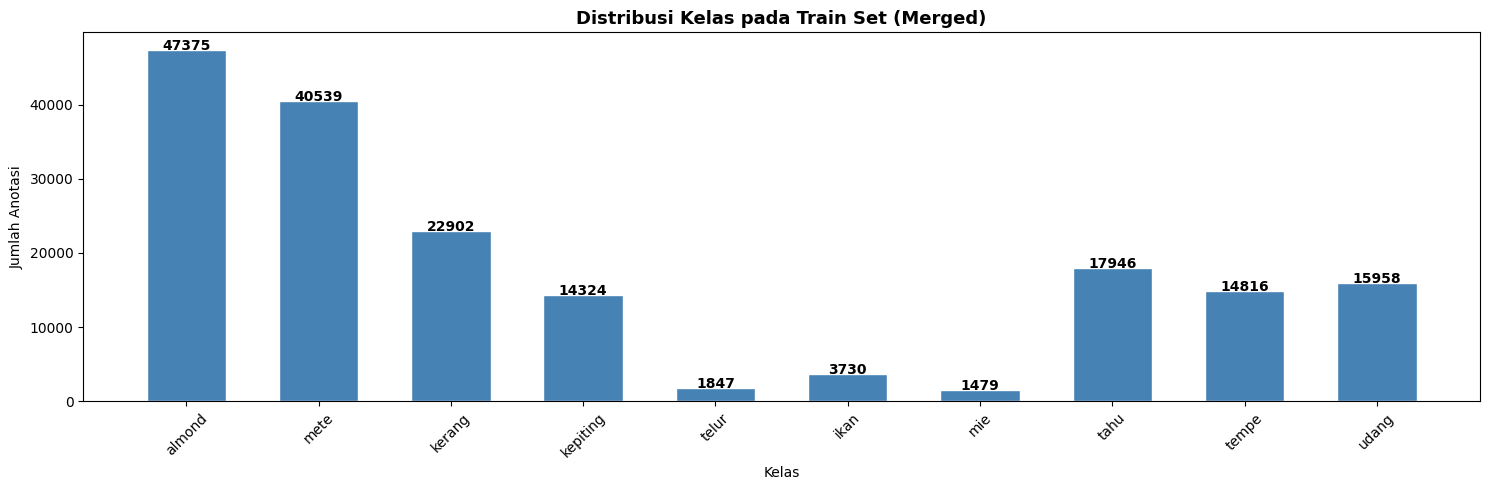


✅ Dataset berhasil digabung!


In [ ]:
import json
import matplotlib.pyplot as plt
import os
from collections import Counter, defaultdict

def merge_coco_jsons(ann_files, img_dirs):
    merged = {
        'images'     : [],
        'annotations': [],
        'categories' : []
    }
    categories_set = {}
    new_img_id     = 1
    new_ann_id     = 1

    for ann_file, img_dir in zip(ann_files, img_dirs):
        with open(ann_file, 'r') as f:
            coco = json.load(f)

        print(f'\n  📄 File: {ann_file}')
        print(f'     Categories : {coco["categories"]}')

        used_cat_ids = set(ann['category_id'] for ann in coco['annotations'])
        print(f'     IDs di anotasi    : {sorted(used_cat_ids)}')
        print(f'     IDs di categories : {[c["id"] for c in coco["categories"]]}')

        # --------------------------------------------------------
        # FIX UTAMA:
        # Buat mapping dari category_id yang ADA di anotasi
        # ke nama kategori yang paling mendekati.
        # Caranya: urutkan keduanya lalu pasangkan satu per satu.
        # --------------------------------------------------------
        sorted_cat_ids_in_ann  = sorted(used_cat_ids)
        sorted_cat_ids_in_def  = sorted(c['id'] for c in coco['categories'])
        cat_id_to_name_def     = {c['id']: c['name'] for c in coco['categories']}

        # Buat mapping: id_di_anotasi -> nama_kelas
        ann_id_to_name = {}

        if sorted_cat_ids_in_ann == sorted_cat_ids_in_def:
            # Case 1: ID cocok sempurna → langsung pakai
            for cat in coco['categories']:
                ann_id_to_name[cat['id']] = cat['name']
            print(f'     ✅ ID cocok sempurna')

        elif len(sorted_cat_ids_in_ann) == len(sorted_cat_ids_in_def):
            # Case 2: Jumlah sama tapi ID berbeda → pasangkan berdasarkan urutan
            for ann_id, def_id in zip(sorted_cat_ids_in_ann, sorted_cat_ids_in_def):
                ann_id_to_name[ann_id] = cat_id_to_name_def[def_id]
            print(f'     ⚠️  ID tidak cocok, dipasangkan berdasarkan urutan:')
            for ann_id, name in ann_id_to_name.items():
                print(f'        category_id {ann_id} → "{name}"')

        else:
            # Case 3: Jumlah berbeda → fallback pakai nama dari categories jika ada
            for cat in coco['categories']:
                ann_id_to_name[cat['id']] = cat['name']
            for cat_id in used_cat_ids:
                if cat_id not in ann_id_to_name:
                    # Coba cari nama terdekat berdasarkan selisih ID terkecil
                    closest = min(coco['categories'],
                                  key=lambda c: abs(c['id'] - cat_id))
                    ann_id_to_name[cat_id] = closest['name']
                    print(f'     ⚠️  category_id {cat_id} tidak ada, '
                          f'dipetakan ke "{closest["name"]}"')

        # Daftarkan semua nama ke merged categories
        old_cat_id_map = {}
        for ann_cat_id, cat_name in ann_id_to_name.items():
            if cat_name not in categories_set:
                categories_set[cat_name] = len(categories_set) + 1
                merged['categories'].append({
                    'id'  : categories_set[cat_name],
                    'name': cat_name
                })
            old_cat_id_map[ann_cat_id] = categories_set[cat_name]

        # Remap image_id
        old_img_id_map = {}
        for img in coco['images']:
            old_img_id_map[img['id']] = new_img_id
            merged['images'].append({
                'id'       : new_img_id,
                'file_name': img['file_name'],
                'width'    : img.get('width',  640),
                'height'   : img.get('height', 640),
                'img_dir'  : img_dir
            })
            new_img_id += 1

        # Remap annotation
        skipped = 0
        for ann in coco['annotations']:
            if ann['image_id'] not in old_img_id_map:
                skipped += 1
                continue
            if ann['category_id'] not in old_cat_id_map:
                skipped += 1
                continue

            merged['annotations'].append({
                'id'          : new_ann_id,
                'image_id'    : old_img_id_map[ann['image_id']],
                'category_id' : old_cat_id_map[ann['category_id']],
                'bbox'        : ann['bbox'],
                'area'        : ann.get('area', 0),
                'segmentation': ann.get('segmentation', []),
                'iscrowd'     : ann.get('iscrowd', 0)
            })
            new_ann_id += 1

        if skipped > 0:
            print(f'     ⚠️  {skipped} anotasi diskip')

    return merged


# ----------------------------------------------------------------
# Merge semua JSON train, val, test
# ----------------------------------------------------------------
print('Menggabungkan dataset dari semua folder output...')
print('='*60)

train_coco = merge_coco_jsons(all_train_ann_files, all_train_img_dirs)
val_coco   = merge_coco_jsons(all_val_ann_files,   all_val_img_dirs)
test_coco  = merge_coco_jsons(all_test_ann_files,  all_test_img_dirs)

# Buat mapping kategori
categories  = train_coco['categories']
id2label    = {cat['id']: cat['name'] for cat in categories}
label2id    = {cat['name']: cat['id'] for cat in categories}
NUM_CLASSES = len(categories)

# Simpan merged JSON
MERGED_DIR = '/content/dataset_latih_baru_2_70_20_10/merged_dataset'  # ← Simpan merged JSON di lokal juga
os.makedirs(os.path.join(MERGED_DIR, 'train', 'annotations'), exist_ok=True)
os.makedirs(os.path.join(MERGED_DIR, 'valid',   'annotations'), exist_ok=True)
os.makedirs(os.path.join(MERGED_DIR, 'test',  'annotations'), exist_ok=True)

TRAIN_ANN_FILE = os.path.join(MERGED_DIR, 'train', 'annotations', 'instances_train_aug.json')
VAL_ANN_FILE   = os.path.join(MERGED_DIR, 'valid',   'annotations', 'instances_valid.json')
TEST_ANN_FILE  = os.path.join(MERGED_DIR, 'test',  'annotations', 'instances_test.json')

with open(TRAIN_ANN_FILE, 'w') as f: json.dump(train_coco, f)
with open(VAL_ANN_FILE,   'w') as f: json.dump(val_coco,   f)
with open(TEST_ANN_FILE,  'w') as f: json.dump(test_coco,  f)

# Info dataset
print('\n' + '='*55)
print('  INFO DATASET SETELAH DIGABUNG')
print('='*55)
print(f'  Jumlah kelas     : {NUM_CLASSES}')
print(f'  Nama kelas       : {list(id2label.values())}')
print(f'  Train - Gambar   : {len(train_coco["images"])}')
print(f'  Train - Anotasi  : {len(train_coco["annotations"])}')
print(f'  Val   - Gambar   : {len(val_coco["images"])}')
print(f'  Val   - Anotasi  : {len(val_coco["annotations"])}')
print(f'  Test  - Gambar   : {len(test_coco["images"])}')
print(f'  Test  - Anotasi  : {len(test_coco["annotations"])}')

# Visualisasi distribusi kelas
cat_count = Counter(ann['category_id'] for ann in train_coco['annotations'])
names  = [id2label[k] for k in sorted(cat_count.keys())]
counts = [cat_count[k] for k in sorted(cat_count.keys())]

fig, ax = plt.subplots(figsize=(max(10, NUM_CLASSES * 1.5), 5))
bars = ax.bar(names, counts, color='steelblue', edgecolor='white', width=0.6)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, str(cnt),
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('Distribusi Kelas pada Train Set (Merged)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas')
ax.set_ylabel('Jumlah Anotasi')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'distribusi_kelas.png'), dpi=150)
plt.show()
print('\n✅ Dataset berhasil digabung!')

##  CELL 6 — Preprocessing: Dataset Class + DataLoader

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DetrImageProcessor
from PIL import Image
import os
import json
from collections import defaultdict

# ============================================================
# PATH DATASET — GUNAKAN LOKAL COLAB
# ============================================================
BASE_DIR = '/content/dataset_latih_baru_2_70_20_10/merged_dataset'  # ← UBAH INI (dari Drive ke lokal)

TRAIN_ANN_FILE = os.path.join(BASE_DIR, 'train', 'annotations', 'instances_train_aug.json')
VAL_ANN_FILE   = os.path.join(BASE_DIR, 'valid',     'annotations', 'instances_valid.json')
TEST_ANN_FILE  = os.path.join(BASE_DIR, 'test',      'annotations', 'instances_test.json')

print("🔍 Mengecek keberadaan file JSON...")
all_ok = True
for path, name in zip([TRAIN_ANN_FILE, VAL_ANN_FILE, TEST_ANN_FILE], ["Train", "Valid", "Test"]):
    if os.path.exists(path):
        print(f"  ✅ {name} JSON ditemukan!")
    else:
        print(f"  ❌ {name} JSON TIDAK ditemukan di: {path}")
        all_ok = False

if not all_ok:
    raise FileNotFoundError("❌ Pastikan path dataset sudah benar!")

# ============================================================
# PROCESSOR
# ============================================================
processor = DetrImageProcessor.from_pretrained(
    CONFIG['model_name'],
    do_resize=False,
    do_pad=False
)
print('✅ DetrImageProcessor loaded (Resize & Pad dimatikan)!')

# ============================================================
# DATASET CLASS
# ============================================================
class CocoDataset(Dataset):
    def __init__(self, ann_file, processor, is_train=False):
        self.processor = processor
        self.is_train  = is_train
        self.img_size  = CONFIG['img_size']

        with open(ann_file, 'r') as f:
            coco_data = json.load(f)

        if "test" in ann_file.lower():
            self.images = coco_data['images']
        else:
            img_ids_with_ann = set(ann['image_id'] for ann in coco_data['annotations'])
            self.images = [img for img in coco_data['images']
                           if img['id'] in img_ids_with_ann]

        split = 'TRAIN' if is_train else 'VAL/TEST'
        print(f'\n📂 [{split}] — Augmentasi online: MATI (data sudah augmentasi offline)')
        print(f'   File                 : {os.path.basename(ann_file)}')
        print(f'   Total gambar di JSON : {len(coco_data["images"])}')
        print(f'   Gambar yang diproses : {len(self.images)}')

        self.ann_by_image = defaultdict(list)
        for ann in coco_data['annotations']:
            self.ann_by_image[ann['image_id']].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_dir  = img_info.get('img_dir', '')
        img_path = os.path.join(img_dir, img_info['file_name'])

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"File fisik tidak ditemukan: {img_path}")

        image = Image.open(img_path).convert('RGB')
        anns  = self.ann_by_image.get(img_info['id'], [])
        valid_anns = [ann for ann in anns
                      if ann['bbox'][2] > 0 and ann['bbox'][3] > 0]

        target = {
            'image_id'   : img_info['id'],
            'annotations': valid_anns
        }

        encoding = self.processor(
            images=image,
            annotations=target,
            return_tensors='pt'
        )

        pixel_values = encoding['pixel_values'].squeeze(0)
        raw_labels = encoding['labels'][0]
        labels = {}
        for k, v in raw_labels.items():
            if k == 'class_labels':
                labels[k] = v.reshape(-1)
            elif k == 'boxes':
                labels[k] = v.reshape(-1, 4)
            else:
                labels[k] = v

        return pixel_values, labels


# ============================================================
# COLLATE FN
# ============================================================
def collate_fn(batch):
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        return None
    pixel_values = torch.stack([item[0] for item in batch])
    labels       = [item[1] for item in batch]
    return {'pixel_values': pixel_values, 'labels': labels}


# ============================================================
# BUAT DATASET & DATALOADER
# num_workers=4 lebih optimal di Colab GPU
# ============================================================
train_dataset = CocoDataset(TRAIN_ANN_FILE, processor, is_train=False)
val_dataset   = CocoDataset(VAL_ANN_FILE,   processor, is_train=False)
test_dataset  = CocoDataset(TEST_ANN_FILE,  processor, is_train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,      # ← NAIK dari 2 ke 4
    pin_memory=True,
    persistent_workers=True   # ← TAMBAH: worker tidak di-restart tiap epoch
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,      # ← NAIK dari 2 ke 4
    pin_memory=True,
    persistent_workers=True   # ← TAMBAH
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4
)

print('\n✅ Dataset & DataLoader siap!')
print(f'   Train : {len(train_dataset):>4} gambar  |  {len(train_loader):>3} batch')
print(f'   Val   : {len(val_dataset):>4} gambar  |  {len(val_loader):>3} batch')
print(f'   Test  : {len(test_dataset):>4} gambar  |  {len(test_loader):>3} batch')
print('\n🚀 Dataset dibaca dari lokal Colab (bukan Drive) — I/O jauh lebih cepat!')

🔍 Mengecek keberadaan file JSON...
  ✅ Train JSON ditemukan!
  ✅ Valid JSON ditemukan!
  ✅ Test JSON ditemukan!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

✅ DetrImageProcessor loaded (Resize & Pad dimatikan)!

📂 [VAL/TEST] — Augmentasi online: MATI (data sudah augmentasi offline)
   File                 : instances_train_aug.json
   Total gambar di JSON : 11200
   Gambar yang diproses : 11200

📂 [VAL/TEST] — Augmentasi online: MATI (data sudah augmentasi offline)
   File                 : instances_valid.json
   Total gambar di JSON : 200
   Gambar yang diproses : 200

📂 [VAL/TEST] — Augmentasi online: MATI (data sudah augmentasi offline)
   File                 : instances_test.json
   Total gambar di JSON : 100
   Gambar yang diproses : 100

✅ Dataset & DataLoader siap!
   Train : 11200 gambar  |  350 batch
   Val   :  200 gambar  |    7 batch
   Test  :  100 gambar  |  100 batch

🚀 Dataset dibaca dari lokal Colab (bukan Drive) — I/O jauh lebih cepat!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

##  CELL 7 — Load Model DETR Pretrained (Bobot COCO)

  ANALISIS DISTRIBUSI ANOTASI PER KELAS
  ID   Nama              Jumlah    Rasio   Weight
  ──────────────────────────────────────────────────
  [ 1] almond             47375 ( 26.2%)    0.115  ✅ DOMINAN
  [ 2] mete               40539 ( 22.4%)    0.135
  [ 3] kerang             22902 ( 12.7%)    0.239
  [ 4] kepiting           14324 (  7.9%)    0.381
  [ 5] telur               1847 (  1.0%)    2.957
  [ 6] ikan                3730 (  2.1%)    1.464
  [ 7] mie                 1479 (  0.8%)    3.693
  [ 8] tahu               17946 (  9.9%)    0.304
  [ 9] tempe              14816 (  8.2%)    0.369
  [10] udang              15958 (  8.8%)    0.342

  Total anotasi    : 180916
  Imbalance ratio  : 32.03× (almond vs mie)
  Threshold aktif  : 1.5×

  ⚖️  IMBALANCE TERDETEKSI (32.03× > 1.5×)
     Class weights DIAKTIFKAN secara otomatis.
     Kelas langka akan mendapat bobot lebih besar pada loss CE.

  Weight tensor (panjang 11):
    [ 0] almond          → 0.1153
    [ 1] mete            → 

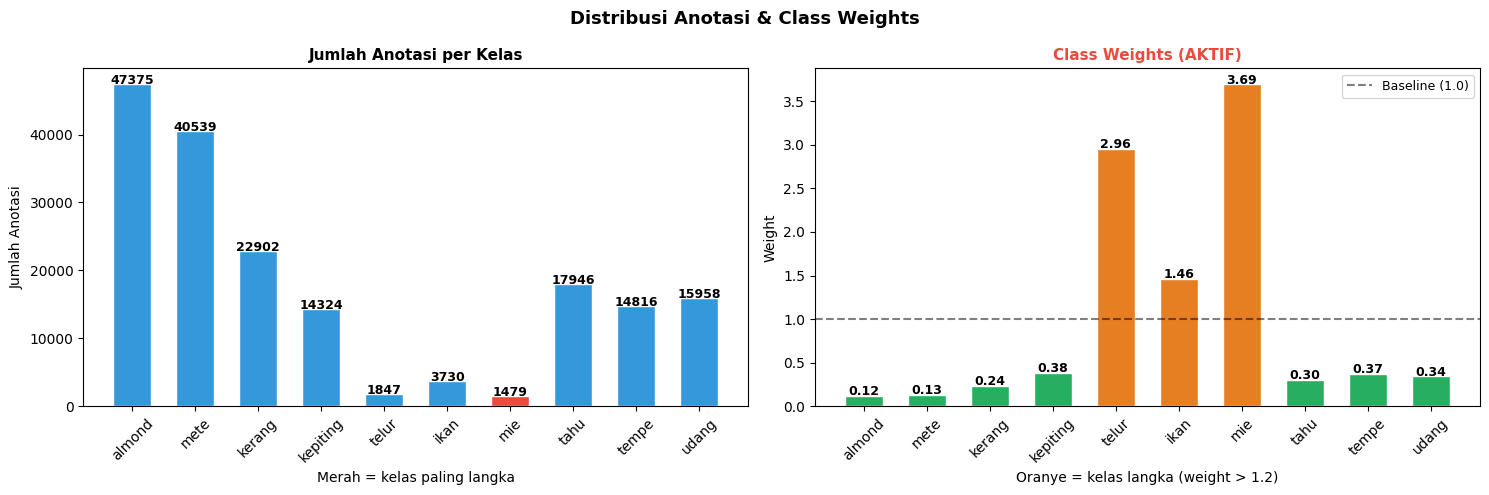


⚖️  Class Weights AKTIF — lanjutkan ke Cell 8.


In [ ]:
# ========================================================
# CELL 7 — Analisis Distribusi + Auto Class Weight
# ========================================================

import json, torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

with open(TRAIN_ANN_FILE) as f:
    train_data = json.load(f)

ann_counts = Counter(ann['category_id'] for ann in train_data['annotations'])

total_ann = sum(ann_counts.values())
max_count = max(ann_counts.values())
min_count = min(ann_counts.values())
imbalance_ratio = max_count / min_count

# ================================================================
# THRESHOLD OTOMATIS: gunakan class weights jika imbalance > 1.5×
# ================================================================
IMBALANCE_THRESHOLD = 1.5
USE_CLASS_WEIGHTS   = imbalance_ratio > IMBALANCE_THRESHOLD

print('='*60)
print('  ANALISIS DISTRIBUSI ANOTASI PER KELAS')
print('='*60)
print(f'  {"ID":<4} {"Nama":<15} {"Jumlah":>8} {"Rasio":>8} {"Weight":>8}')
print('  ' + '─' * 50)

# ----------------------------------------------------------------
# Hitung class weights dengan metode Inverse Frequency
# weight[i] = total_ann / (num_classes * count[i])
# Kelas langka → weight besar, kelas dominan → weight kecil
# ----------------------------------------------------------------
num_classes_for_weight = len(ann_counts)
raw_weights = {}
for cat_id, count in ann_counts.items():
    raw_weights[cat_id] = total_ann / (num_classes_for_weight * count)

# Normalisasi: mean weight = 1.0 agar skala loss tidak berubah
mean_w = np.mean(list(raw_weights.values()))
normalized_weights = {cat_id: w / mean_w for cat_id, w in raw_weights.items()}

for cat_id in sorted(ann_counts):
    name  = id2label.get(cat_id, f'id_{cat_id}')
    count = ann_counts[cat_id]
    rasio = count / total_ann * 100
    w     = normalized_weights[cat_id]
    flag  = ' ⚠️  LANGKA' if count < 500 else ('  ✅ DOMINAN' if count == max_count else '')
    print(f'  [{cat_id:2d}] {name:<15} {count:>8} ({rasio:5.1f}%) {w:>8.3f}{flag}')

print(f'\n  Total anotasi    : {total_ann}')
print(f'  Imbalance ratio  : {imbalance_ratio:.2f}× '
      f'({id2label[max(ann_counts, key=ann_counts.get)]} vs '
      f'{id2label[min(ann_counts, key=ann_counts.get)]})')
print(f'  Threshold aktif  : {IMBALANCE_THRESHOLD}×')

if USE_CLASS_WEIGHTS:
    print(f'\n  ⚖️  IMBALANCE TERDETEKSI ({imbalance_ratio:.2f}× > {IMBALANCE_THRESHOLD}×)')
    print(f'     Class weights DIAKTIFKAN secara otomatis.')
    print(f'     Kelas langka akan mendapat bobot lebih besar pada loss CE.')
else:
    print(f'\n  ✅ Dataset SEIMBANG ({imbalance_ratio:.2f}× ≤ {IMBALANCE_THRESHOLD}×)')
    print(f'     Class weights TIDAK digunakan.')
    print(f'     Model menggunakan bobot default DETR (semua kelas = 1.0)')

# ----------------------------------------------------------------
# Simpan ke CONFIG agar bisa diakses Cell 8
# ----------------------------------------------------------------
CONFIG['use_class_weights']   = USE_CLASS_WEIGHTS
CONFIG['imbalance_ratio']     = round(imbalance_ratio, 2)
CONFIG['imbalance_threshold'] = IMBALANCE_THRESHOLD

# Buat tensor weight untuk semua class_id (termasuk background di index 0 = 1.0)
# DETR memakai num_classes+1 logits, background ada di indeks terakhir (num_classes)
# → weight tensor panjangnya num_classes+1, semua background = 1.0
sorted_cat_ids    = sorted(ann_counts.keys())   # [1, 2, ..., N]
num_obj_classes   = len(sorted_cat_ids)

# weight_tensor[i] sesuai indeks class_label yang dipakai DETR
# DETR: class 0 s/d num_classes-1 = objek, class num_classes = no-object (background)
class_weight_list = []
for cat_id in range(1, num_obj_classes + 1):
    class_weight_list.append(normalized_weights.get(cat_id, 1.0))
class_weight_list.append(1.0)   # background / no-object tetap 1.0

CLASS_WEIGHT_TENSOR = torch.tensor(class_weight_list, dtype=torch.float32)

print(f'\n  Weight tensor (panjang {len(CLASS_WEIGHT_TENSOR)}):')
for i, w in enumerate(CLASS_WEIGHT_TENSOR):
    # i=0 adalah untuk class_id=1 (almond), dan indeks terakhir adalah background
    if i < num_obj_classes:
        name = id2label.get(i + 1, f'id_{i+1}') # <--- Tambahkan + 1 di sini
    else:
        name = 'background'

    print(f'    [{i:2d}] {name:<15} → {w.item():.4f}')

# ----------------------------------------------------------------
# Visualisasi distribusi + weight (bar chart ganda)
# ----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(14, num_obj_classes * 1.5), 5))
fig.suptitle('Distribusi Anotasi & Class Weights', fontsize=13, fontweight='bold')

names_sorted  = [id2label.get(cid, f'id_{cid}') for cid in sorted_cat_ids]
counts_sorted = [ann_counts[cid] for cid in sorted_cat_ids]
weights_sorted = [normalized_weights[cid] for cid in sorted_cat_ids]

# Bar kiri: distribusi anotasi
bars1 = ax1.bar(names_sorted, counts_sorted,
                color=['#e74c3c' if c == min_count else '#3498db' for c in counts_sorted],
                edgecolor='white', width=0.6)
for bar, cnt in zip(bars1, counts_sorted):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(cnt), ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Jumlah Anotasi per Kelas', fontsize=11, fontweight='bold')
ax1.set_ylabel('Jumlah Anotasi')
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel('Merah = kelas paling langka')

# Bar kanan: class weights
bar_colors = ['#e67e22' if w > 1.2 else ('#27ae60' if w < 0.8 else '#95a5a6')
              for w in weights_sorted]
bars2 = ax2.bar(names_sorted, weights_sorted, color=bar_colors, edgecolor='white', width=0.6)
ax2.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Baseline (1.0)')
for bar, w in zip(bars2, weights_sorted):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{w:.2f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_title(f'Class Weights ({"AKTIF" if USE_CLASS_WEIGHTS else "NONAKTIF — dataset seimbang"})',
              fontsize=11, fontweight='bold',
              color='#e74c3c' if USE_CLASS_WEIGHTS else '#27ae60')
ax2.set_ylabel('Weight')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=9)
ax2.set_xlabel('Oranye = kelas langka (weight > 1.2)')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'class_weights_distribusi.png'), dpi=150, bbox_inches='tight')
plt.show()

status = "⚖️  Class Weights AKTIF" if USE_CLASS_WEIGHTS else "✅ Weights NONAKTIF (dataset seimbang)"
print(f'\n{status} — lanjutkan ke Cell 8.')

##  CELL 8 — Training Loop (Fine-Tuning DETR + Hungarian Loss)

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# ========================================================
# CELL 8: Inisialisasi Model + Optimizer + Training Loop
#         VERSI LENGKAP — Scheduler + Accuracy + History
# ========================================================

import torch
import torch.nn.functional as F
from transformers import DetrForObjectDetection, DetrImageProcessor
from transformers.models.detr.modeling_detr import DetrLoss, DetrHungarianMatcher
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import time, os, json, gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision.ops import nms
from collections import defaultdict

# ── 1. BERSIHKAN MEMORI ──
gc.collect()
torch.cuda.empty_cache()

# ================================================================
# 2. CUSTOM WEIGHTED DETR LOSS
# ================================================================
class WeightedDetrLoss(DetrLoss):
    def __init__(self, matcher, num_classes, eos_coef, losses,
                 class_weight_tensor):
        super().__init__(matcher, num_classes, eos_coef, losses)
        del self.empty_weight
        self.register_buffer(
            'empty_weight', class_weight_tensor.clone().float()
        )

    def _get_src_permutation_idx(self, indices):
        batch_idx = torch.cat([
            torch.full_like(src, i)
            for i, (src, _) in enumerate(indices)
        ])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx

    def loss_labels(self, outputs, targets, indices, num_boxes):
        logits_key = 'logits' if 'logits' in outputs else 'pred_logits'
        src_logits = outputs[logits_key]

        idx = self._get_src_permutation_idx(indices)
        target_classes_o = torch.cat([
            t['class_labels'][J]
            for t, (_, J) in zip(targets, indices)
        ])

        target_classes = torch.full(
            src_logits.shape[:2], self.num_classes,
            dtype=torch.int64, device=src_logits.device
        )
        target_classes[idx] = target_classes_o

        loss_ce = F.cross_entropy(
            src_logits.transpose(1, 2),
            target_classes,
            weight=self.empty_weight
        )

        losses = {'loss_ce': loss_ce}
        if logits_key in outputs:
            losses['class_error'] = (
                100 - self._accuracy(
                    src_logits[idx], target_classes_o
                )[0]
            )
        return losses

    @staticmethod
    def _accuracy(output, target, topk=(1,)):
        with torch.no_grad():
            maxk       = max(topk)
            batch_size = target.size(0)
            if batch_size == 0:
                return [torch.tensor(0.0)]
            _, pred = output.topk(maxk, 1, True, True)
            pred    = pred.t()
            correct = pred.eq(target.view(1, -1).expand_as(pred))
            res = []
            for k in topk:
                correct_k = (
                    correct[:k].reshape(-1)
                    .float().sum(0, keepdim=True)
                )
                res.append(correct_k.mul_(100.0 / batch_size))
            return res


# ================================================================
# 3. HELPER HITUNG LOSS
# ================================================================
def compute_weighted_loss(loss_dict, weight_dict):
    loss = 0.0
    for k, v in loss_dict.items():
        base_k = (
            k.rsplit('_', 1)[0]
            if ('_' in k and k.split('_')[-1].isdigit())
            else k
        )
        w    = weight_dict.get(base_k, 1.0)
        loss = loss + (v.mean() * w)
    return loss


# ================================================================
# 4. HELPER HITUNG AKURASI KLASIFIKASI
# ================================================================
def compute_classification_accuracy(outputs, targets):
    """
    Mengukur seberapa banyak object query yang berhasil
    memprediksi kelas yang sama dengan ground truth.
    Nilai 0.0 – 1.0 (semakin tinggi semakin baik).
    """
    correct = 0
    total   = 0
    with torch.no_grad():
        logits       = outputs.logits          # [B, 100, C+1]
        pred_classes = logits.argmax(dim=-1)   # [B, 100]

        for b, target in enumerate(targets):
            gt_labels = target['class_labels']
            if len(gt_labels) == 0:
                continue
            n_gt      = len(gt_labels)
            top_preds = pred_classes[b, :n_gt]
            for gt in gt_labels:
                if gt in top_preds:
                    correct += 1
                total += 1

    return correct / total if total > 0 else 0.0


# ================================================================
# 5. INISIALISASI MODEL
# ================================================================
print(f"\nInisialisasi model: {CONFIG['model_name']}...")

id2label_with_bg = {0: 'background'}
for k, v in id2label.items():
    id2label_with_bg[int(k)] = v
label2id_with_bg = {v: k for k, v in id2label_with_bg.items()}

model = DetrForObjectDetection.from_pretrained(
    CONFIG['model_name'],
    id2label              = id2label_with_bg,
    label2id              = label2id_with_bg,
    ignore_mismatched_sizes = True
)
model.to(CONFIG['device'])

# ================================================================
# 6. SETUP WEIGHT TENSOR & LOSS DICTIONARY
# ================================================================
custom_loss_fn = None

detr_weight_dict = {
    'loss_ce':          1.0,
    'loss_bbox':        getattr(model.config, 'bbox_loss_coefficient', 5.0),
    'loss_giou':        getattr(model.config, 'giou_loss_coefficient', 2.0),
    'loss_cardinality': 0.0
}

if CONFIG.get('use_class_weights', False):
    eos_coef             = 0.1
    expected_logits_dim  = model.config.num_labels + 1
    weighted_tensor      = torch.ones(expected_logits_dim)

    for i in range(min(len(CLASS_WEIGHT_TENSOR), expected_logits_dim - 1)):
        weighted_tensor[i] = CLASS_WEIGHT_TENSOR[i]
    weighted_tensor[-1] = eos_coef

    matcher = DetrHungarianMatcher(
        class_cost=1.0, bbox_cost=5.0, giou_cost=2.0
    )
    custom_loss_fn = WeightedDetrLoss(
        matcher             = matcher,
        num_classes         = model.config.num_labels,
        eos_coef            = eos_coef,
        losses              = ["labels", "boxes", "cardinality"],
        class_weight_tensor = weighted_tensor.to(CONFIG['device'])
    )
    print(f"✅ Weighted Loss SINKRON! "
          f"Panjang tensor bobot = {len(weighted_tensor)}")

# ================================================================
# 7. GRADIENT ACCUMULATION
# ================================================================
TARGET_BATCH_SIZE  = 32
CURRENT_BATCH_SIZE = CONFIG.get('batch_size', 2)
ACCUMULATION_STEPS = max(1, TARGET_BATCH_SIZE // CURRENT_BATCH_SIZE)

# ================================================================
# 8. FUNGSI EVALUASI mAP
# ================================================================
def run_milestone_eval(eval_model, eval_processor,
                       milestone_epoch, label_suffix):
    eval_model.eval()
    preds_list = []

    with torch.no_grad():
        for batch in test_loader:
            if batch is None:
                continue
            pixel_values = batch['pixel_values'].to(CONFIG['device'])
            labels_batch = batch['labels']
            outputs_inf  = eval_model(pixel_values=pixel_values)
            target_sizes = torch.tensor(
                [[CONFIG['img_size'], CONFIG['img_size']]]
                * len(labels_batch)
            )
            results = eval_processor.post_process_object_detection(
                outputs_inf,
                threshold    = CONFIG['conf_threshold'],
                target_sizes = target_sizes
            )

            for i, result in enumerate(results):
                boxes, scores, labels_r = (
                    result['boxes'],
                    result['scores'],
                    result['labels']
                )
                if len(boxes) == 0:
                    continue

                keep_idxs = []
                for cls_id in labels_r.unique():
                    mask = labels_r == cls_id
                    keep = nms(boxes[mask], scores[mask], 0.5)
                    keep_idxs.append(
                        mask.nonzero(as_tuple=True)[0][keep]
                    )

                if not keep_idxs:
                    continue
                keep_idxs = torch.cat(keep_idxs)
                img_id    = labels_batch[i]['image_id'].item()

                for box, score, cls_id in zip(
                    boxes[keep_idxs],
                    scores[keep_idxs],
                    labels_r[keep_idxs]
                ):
                    x1, y1, x2, y2 = box.cpu().numpy()
                    preds_list.append({
                        'image_id':    int(img_id),
                        'category_id': int(cls_id),
                        'bbox':  [float(x1), float(y1),
                                  float(x2 - x1), float(y2 - y1)],
                        'score': float(score)
                    })

    tmp_path = os.path.join(
        CONFIG['output_dir'], f'preds_{label_suffix}.json'
    )
    with open(tmp_path, 'w') as f:
        json.dump(preds_list, f)

    metrics = {
        'mAP_50': 0.0, 'mAP_75': 0.0, 'mAP_50_95': 0.0,
        'mAR_1':  0.0, 'mAR_10': 0.0, 'mAR_100':   0.0
    }

    if len(preds_list) > 0:
        try:
            coco_gt   = COCO(TEST_ANN_FILE)
            coco_dt   = coco_gt.loadRes(tmp_path)
            coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
            coco_eval.evaluate()
            coco_eval.accumulate()
            coco_eval.summarize()
            metrics['mAP_50_95'] = round(coco_eval.stats[0], 4)
            metrics['mAP_50']    = round(coco_eval.stats[1], 4)
            metrics['mAP_75']    = round(coco_eval.stats[2], 4)
            metrics['mAR_1']     = round(coco_eval.stats[6], 4)
            metrics['mAR_10']    = round(coco_eval.stats[7], 4)
            metrics['mAR_100']   = round(coco_eval.stats[8], 4)
        except Exception as e:
            print(f"  ⚠️ Eval error: {e}")

    return {**metrics, 'epoch': milestone_epoch, 'label': label_suffix}


# ================================================================
# 9. OPTIMIZER + COSINE SCHEDULER
# ================================================================
param_dicts = [
    {
        'params': [
            p for n, p in model.named_parameters()
            if 'backbone' in n and p.requires_grad
        ],
        'lr': CONFIG['lr_backbone']
    },
    {
        'params': [
            p for n, p in model.named_parameters()
            if 'backbone' not in n and p.requires_grad
        ],
        'lr': CONFIG['learning_rate']
    }
]

optimizer = AdamW(param_dicts, weight_decay=CONFIG['weight_decay'])

# Cosine scheduler: LR turun halus dari lr_awal ke 1e-6
scheduler = CosineAnnealingLR(
    optimizer,
    T_max   = CONFIG['num_epochs'],
    eta_min = 1e-6
)

scaler = torch.amp.GradScaler('cuda')

print('\n' + '=' * 65)
print(f'  STARTING TRAINING')
print(f'  Device             : {CONFIG["device"]}')
print(f'  Physical Batch     : {CURRENT_BATCH_SIZE}')
print(f'  Accumulation Steps : {ACCUMULATION_STEPS} '
      f'(Setara Batch {CURRENT_BATCH_SIZE * ACCUMULATION_STEPS})')
print(f'  Scheduler          : CosineAnnealingLR (eta_min=1e-6)')
print(f'  Total Epochs       : {CONFIG["num_epochs"]}')
print('=' * 65 + '\n')

# ================================================================
# 10. VARIABEL TRACKING
# ================================================================
best_val_loss       = float('inf')
best_map50          = 0.0
patience_counter    = 0
_current_best_epoch = 0

best_model_path = os.path.join(
    CONFIG['output_dir'], 'checkpoints', 'best_model'
)
os.makedirs(best_model_path, exist_ok=True)

history           = defaultdict(list)
MILESTONES        = [50, 100, 200]
EVAL_INTERVAL     = 10
milestone_results = {}


def get_loss_value(loss_dict, key):
    val = loss_dict.get(key, 0)
    return val.item() if isinstance(val, torch.Tensor) else float(val)


# ================================================================
# 11. TRAINING LOOP UTAMA
# ================================================================
for epoch in range(1, CONFIG['num_epochs'] + 1):
    t_start = time.time()

    # ─────────────────────────────────────
    # FASE TRAINING
    # ─────────────────────────────────────
    model.train()
    train_metrics = defaultdict(float)
    train_acc_sum = 0.0
    n_train       = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        if batch is None:
            continue

        pixel_values = batch['pixel_values'].to(CONFIG['device'])
        labels = [
            {k: v.to(CONFIG['device']) for k, v in t.items()}
            for t in batch['labels']
        ]

        with torch.amp.autocast('cuda'):
            outputs = model(pixel_values=pixel_values, labels=labels)

            if custom_loss_fn:
                out_dict = {
                    'logits':     outputs.logits,
                    'pred_boxes': outputs.pred_boxes
                }
                if (hasattr(outputs, 'auxiliary_outputs')
                        and outputs.auxiliary_outputs is not None):
                    out_dict['aux_outputs'] = outputs.auxiliary_outputs

                loss_dict = custom_loss_fn(out_dict, labels)
                loss      = compute_weighted_loss(
                    loss_dict, detr_weight_dict
                )
            else:
                loss      = outputs.loss
                loss_dict = (
                    outputs.loss_dict
                    if hasattr(outputs, 'loss_dict') else {}
                )

            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        # Hitung akurasi klasifikasi per step
        train_acc_sum += compute_classification_accuracy(
            outputs, labels
        )

        if (((step + 1) % ACCUMULATION_STEPS == 0)
                or ((step + 1) == len(train_loader))):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=0.1
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_metrics['loss'] += loss.item() * ACCUMULATION_STEPS
        train_metrics['ce']   += get_loss_value(loss_dict, 'loss_ce')
        train_metrics['bbox'] += get_loss_value(loss_dict, 'loss_bbox')
        train_metrics['giou'] += get_loss_value(loss_dict, 'loss_giou')
        n_train += 1

        del pixel_values, labels, outputs

    # Update LR scheduler setiap akhir epoch
    scheduler.step()

    # ─────────────────────────────────────
    # FASE VALIDASI
    # ─────────────────────────────────────
    model.eval()
    val_metrics = defaultdict(float)
    val_acc_sum = 0.0
    n_val       = 0

    with torch.no_grad():
        for batch in val_loader:
            if batch is None:
                continue

            pixel_values = batch['pixel_values'].to(CONFIG['device'])
            labels = [
                {k: v.to(CONFIG['device']) for k, v in t.items()}
                for t in batch['labels']
            ]

            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values=pixel_values, labels=labels)

                if custom_loss_fn:
                    out_dict = {
                        'logits':     outputs.logits,
                        'pred_boxes': outputs.pred_boxes
                    }
                    if (hasattr(outputs, 'auxiliary_outputs')
                            and outputs.auxiliary_outputs is not None):
                        out_dict['aux_outputs'] = (
                            outputs.auxiliary_outputs
                        )
                    loss_dict = custom_loss_fn(out_dict, labels)
                    v_loss    = compute_weighted_loss(
                        loss_dict, detr_weight_dict
                    )
                else:
                    v_loss    = outputs.loss
                    loss_dict = (
                        outputs.loss_dict
                        if hasattr(outputs, 'loss_dict') else {}
                    )

            val_metrics['loss'] += v_loss.item()
            val_metrics['ce']   += get_loss_value(loss_dict, 'loss_ce')
            val_metrics['bbox'] += get_loss_value(loss_dict, 'loss_bbox')
            val_metrics['giou'] += get_loss_value(loss_dict, 'loss_giou')
            val_acc_sum         += compute_classification_accuracy(
                outputs, labels
            )
            n_val += 1

            del pixel_values, labels, outputs

    # ─────────────────────────────────────
    # HITUNG RATA-RATA & LOGGING
    # ─────────────────────────────────────
    avg_train_loss = train_metrics['loss'] / max(n_train, 1)
    avg_val_loss   = val_metrics['loss']   / max(n_val,   1)
    avg_train_acc  = train_acc_sum          / max(n_train, 1)
    avg_val_acc    = val_acc_sum            / max(n_val,   1)
    current_lr     = scheduler.get_last_lr()[1]

    print(
        f'Epoch [{epoch:03d}/{CONFIG["num_epochs"]}] '
        f'Train Loss: {avg_train_loss:.4f} | '
        f'Val Loss: {avg_val_loss:.4f} | '
        f'Train Acc: {avg_train_acc:.4f} | '
        f'Val Acc: {avg_val_acc:.4f} | '
        f'LR: {current_lr:.2e} | '
        f'Time: {time.time() - t_start:.1f}s'
    )

    # ─────────────────────────────────────
    # SIMPAN KE HISTORY
    # ─────────────────────────────────────
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)
    history['lr'].append(current_lr)
    history['train_loss_ce'].append(
        train_metrics['ce']   / max(n_train, 1)
    )
    history['val_loss_ce'].append(
        val_metrics['ce']     / max(n_val,   1)
    )
    history['train_loss_bbox'].append(
        train_metrics['bbox'] / max(n_train, 1)
    )
    history['val_loss_bbox'].append(
        val_metrics['bbox']   / max(n_val,   1)
    )
    history['train_loss_giou'].append(
        train_metrics['giou'] / max(n_train, 1)
    )
    history['val_loss_giou'].append(
        val_metrics['giou']   / max(n_val,   1)
    )

    # ─────────────────────────────────────
    # MILESTONE SNAPSHOT
    # ─────────────────────────────────────
    if epoch in MILESTONES:
        snap_path = os.path.join(
            CONFIG['output_dir'], 'checkpoints', f'epoch_{epoch}'
        )
        model.save_pretrained(snap_path)

    # ─────────────────────────────────────
    # EVAL mAP SETIAP EVAL_INTERVAL EPOCH
    # ─────────────────────────────────────
    if epoch % EVAL_INTERVAL == 0 or epoch in MILESTONES:
        print(f'  🔍 Running mAP eval @ epoch {epoch}...')
        res_snap = run_milestone_eval(
            model, processor, epoch, f'epoch{epoch}'
        )
        milestone_results[epoch] = res_snap
        history['map50'].append(res_snap['mAP_50'])
        history['map50_95'].append(res_snap['mAP_50_95'])
        history['map_epochs'].append(epoch)

        print(
            f'  📊 mAP@50={res_snap["mAP_50"]:.4f} | '
            f'mAP@75={res_snap["mAP_75"]:.4f} | '
            f'mAP@50:95={res_snap["mAP_50_95"]:.4f} | '
            f'mAR@100={res_snap["mAR_100"]:.4f}'
        )

        if res_snap['mAP_50'] > best_map50:
            best_map50          = res_snap['mAP_50']
            _current_best_epoch = epoch
            patience_counter    = 0
            model.save_pretrained(best_model_path)
            processor.save_pretrained(best_model_path)
            print(f'  ✅ Best model saved '
                  f'(mAP@50={best_map50:.4f})')
        else:
            patience_counter += EVAL_INTERVAL
            print(
                f'  ⏳ No improvement. '
                f'Patience: {patience_counter}/{CONFIG["patience"]}'
            )
    else:
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

    if patience_counter >= CONFIG['patience']:
        print(f'\n🛑 Early stopping triggered @ epoch {epoch}')
        break

print(
    f'\n✅ TRAINING SELESAI | '
    f'Best mAP@50: {best_map50:.4f} @ Epoch {_current_best_epoch}'
)
print(f'   Model tersimpan di: {best_model_path}')


Inisialisasi model: facebook/detr-resnet-50...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

✅ Weighted Loss SINKRON! Panjang tensor bobot = 12

  STARTING TRAINING
  Device             : cuda
  Physical Batch     : 32
  Accumulation Steps : 1 (Setara Batch 32)
  Scheduler          : CosineAnnealingLR (eta_min=1e-6)
  Total Epochs       : 200

Epoch [001/200] Train Loss: 109.4629 | Val Loss: 75.7519 | Train Acc: 0.2247 | Val Acc: 0.5244 | LR: 1.00e-04 | Time: 403.1s
Epoch [002/200] Train Loss: 75.3008 | Val Loss: 61.0842 | Train Acc: 0.6883 | Val Acc: 0.7345 | LR: 1.00e-04 | Time: 399.5s
Epoch [003/200] Train Loss: 52.9724 | Val Loss: 51.7998 | Train Acc: 0.8553 | Val Acc: 0.7718 | LR: 9.99e-05 | Time: 399.0s
Epoch [004/200] Train Loss: 41.5290 | Val Loss: 49.5267 | Train Acc: 0.8943 | Val Acc: 0.7958 | LR: 9.99e-05 | Time: 400.3s
Epoch [005/200] Train Loss: 37.1593 | Val Loss: 50.4476 | Train Acc: 0.9005 | Val Acc: 0.7243 | LR: 9.98e-05 | Time: 398.7s
Epoch [006/200] Train Loss: 33.3015 | Val Loss: 49.1878 | Train Acc: 0.9114 | Val Acc: 0.7496 | LR: 9.98e-05 | Time: 398.7s
Ep

Exception in thread Thread-6 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_s

KeyboardInterrupt: 

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# ================================================================
# CELL 8B — RESUME TRAINING (DARI EPOCH 70)
# ================================================================

import torch
import torch.nn.functional as F
from transformers import DetrForObjectDetection, DetrImageProcessor
from transformers.models.detr.modeling_detr import DetrLoss, DetrHungarianMatcher
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import time, os, json, gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision.ops import nms
from collections import defaultdict

gc.collect()
torch.cuda.empty_cache()

# ================================================================
# ⚙️ SETTING EPOCH TERAKHIR (SESUAI BEST MODEL TERBARU: EPOCH 70)
# ================================================================
LAST_COMPLETED_EPOCH = 70
best_model_path = os.path.join(CONFIG['output_dir'], 'checkpoints', 'best_model')
START_EPOCH     = LAST_COMPLETED_EPOCH + 1

# ================================================================
# CLASS & HELPER
# ================================================================
class WeightedDetrLoss(DetrLoss):
    def __init__(self, matcher, num_classes, eos_coef, losses, class_weight_tensor):
        super().__init__(matcher, num_classes, eos_coef, losses)
        del self.empty_weight
        self.register_buffer('empty_weight', class_weight_tensor.clone().float())

    def _get_src_permutation_idx(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx

    def loss_labels(self, outputs, targets, indices, num_boxes):
        logits_key = 'logits' if 'logits' in outputs else 'pred_logits'
        src_logits = outputs[logits_key]
        idx = self._get_src_permutation_idx(indices)
        target_classes_o = torch.cat([t['class_labels'][J] for t, (_, J) in zip(targets, indices)])
        target_classes = torch.full(src_logits.shape[:2], self.num_classes, dtype=torch.int64, device=src_logits.device)
        target_classes[idx] = target_classes_o
        loss_ce = F.cross_entropy(src_logits.transpose(1, 2), target_classes, weight=self.empty_weight)
        losses = {'loss_ce': loss_ce}
        if logits_key in outputs:
            losses['class_error'] = 100 - self._accuracy(src_logits[idx], target_classes_o)[0]
        return losses

    @staticmethod
    def _accuracy(output, target, topk=(1,)):
        with torch.no_grad():
            maxk = max(topk)
            batch_size = target.size(0)
            if batch_size == 0: return [torch.tensor(0.0)]
            _, pred = output.topk(maxk, 1, True, True)
            pred = pred.t()
            correct = pred.eq(target.view(1, -1).expand_as(pred))
            res = []
            for k in topk:
                correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
                res.append(correct_k.mul_(100.0 / batch_size))
            return res

def compute_weighted_loss(loss_dict, weight_dict):
    loss = 0.0
    for k, v in loss_dict.items():
        base_k = k.rsplit('_', 1)[0] if ('_' in k and k.split('_')[-1].isdigit()) else k
        w = weight_dict.get(base_k, 1.0)
        loss = loss + (v.mean() * w)
    return loss

def compute_classification_accuracy(outputs, targets):
    correct, total = 0, 0
    with torch.no_grad():
        logits = outputs.logits
        pred_classes = logits.argmax(dim=-1)
        for b, target in enumerate(targets):
            gt_labels = target['class_labels']
            if len(gt_labels) == 0: continue
            top_preds = pred_classes[b, :len(gt_labels)]
            for gt in gt_labels:
                if gt in top_preds: correct += 1
                total += 1
    return correct / total if total > 0 else 0.0

def get_loss_value(loss_dict, key):
    val = loss_dict.get(key, 0)
    return val.item() if isinstance(val, torch.Tensor) else float(val)

def run_milestone_eval(eval_model, eval_processor, milestone_epoch, label_suffix):
    eval_model.eval()
    preds_list = []
    with torch.no_grad():
        for batch in test_loader:
            if batch is None: continue
            pixel_values = batch['pixel_values'].to(CONFIG['device'])
            labels_batch = batch['labels']
            outputs_inf  = eval_model(pixel_values=pixel_values)
            target_sizes = torch.tensor([[CONFIG['img_size'], CONFIG['img_size']]] * len(labels_batch))
            results = eval_processor.post_process_object_detection(outputs_inf, threshold=CONFIG['conf_threshold'], target_sizes=target_sizes)
            for i, result in enumerate(results):
                boxes, scores, labels_r = result['boxes'], result['scores'], result['labels']
                if len(boxes) == 0: continue
                keep_idxs = []
                for cls_id in labels_r.unique():
                    mask = labels_r == cls_id
                    keep = nms(boxes[mask], scores[mask], 0.5)
                    keep_idxs.append(mask.nonzero(as_tuple=True)[0][keep])
                if not keep_idxs: continue
                keep_idxs = torch.cat(keep_idxs)
                img_id = labels_batch[i]['image_id'].item()
                for box, score, cls_id in zip(boxes[keep_idxs], scores[keep_idxs], labels_r[keep_idxs]):
                    x1, y1, x2, y2 = box.cpu().numpy()
                    preds_list.append({
                        'image_id': int(img_id),
                        'category_id': int(cls_id),
                        'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        'score': float(score)
                    })
    tmp_path = os.path.join(CONFIG['output_dir'], f'preds_{label_suffix}.json')
    with open(tmp_path, 'w') as f: json.dump(preds_list, f)
    metrics = {'mAP_50': 0.0, 'mAP_75': 0.0, 'mAP_50_95': 0.0, 'mAR_1': 0.0, 'mAR_10': 0.0, 'mAR_100': 0.0}
    if len(preds_list) > 0:
        try:
            coco_gt = COCO(TEST_ANN_FILE)
            coco_dt = coco_gt.loadRes(tmp_path)
            coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
            coco_eval.evaluate(); coco_eval.accumulate(); coco_eval.summarize()
            metrics['mAP_50_95'] = round(coco_eval.stats[0], 4)
            metrics['mAP_50']    = round(coco_eval.stats[1], 4)
            metrics['mAP_75']    = round(coco_eval.stats[2], 4)
            metrics['mAR_1']     = round(coco_eval.stats[6], 4)
            metrics['mAR_10']    = round(coco_eval.stats[7], 4)
            metrics['mAR_100']   = round(coco_eval.stats[8], 4)
        except Exception as e:
            print(f"  ⚠️ Eval error: {e}")
    return {**metrics, 'epoch': milestone_epoch, 'label': label_suffix}

# ================================================================
# LOAD MODEL DARI CHECKPOINT
# ================================================================
print(f"🔄 Memuat model dari checkpoint: {best_model_path}")

id2label_with_bg = {0: 'background'}
for k, v in id2label.items(): id2label_with_bg[int(k)] = v
label2id_with_bg = {v: k for k, v in id2label_with_bg.items()}

model = DetrForObjectDetection.from_pretrained(
    best_model_path,
    id2label=id2label_with_bg,
    label2id=label2id_with_bg,
    ignore_mismatched_sizes=False
)
model.to(CONFIG['device'])
processor = DetrImageProcessor.from_pretrained(best_model_path)
print("✅ Model & processor berhasil dimuat!")

# ================================================================
# SETUP WEIGHTED LOSS
# ================================================================
custom_loss_fn = None
detr_weight_dict = {
    'loss_ce': 1.0,
    'loss_bbox': getattr(model.config, 'bbox_loss_coefficient', 5.0),
    'loss_giou': getattr(model.config, 'giou_loss_coefficient', 2.0),
    'loss_cardinality': 0.0
}

if CONFIG.get('use_class_weights', False):
    eos_coef = 0.1
    expected_logits_dim = model.config.num_labels + 1
    weighted_tensor = torch.ones(expected_logits_dim)
    for i in range(min(len(CLASS_WEIGHT_TENSOR), expected_logits_dim - 1)):
        weighted_tensor[i] = CLASS_WEIGHT_TENSOR[i]
    weighted_tensor[-1] = eos_coef
    matcher = DetrHungarianMatcher(class_cost=1.0, bbox_cost=5.0, giou_cost=2.0)
    custom_loss_fn = WeightedDetrLoss(
        matcher=matcher, num_classes=model.config.num_labels,
        eos_coef=eos_coef, losses=["labels", "boxes", "cardinality"],
        class_weight_tensor=weighted_tensor.to(CONFIG['device'])
    )

# ================================================================
# GRADIENT ACCUMULATION
# ================================================================
TARGET_BATCH_SIZE  = 32
CURRENT_BATCH_SIZE = CONFIG.get('batch_size', 2)
ACCUMULATION_STEPS = max(1, TARGET_BATCH_SIZE // CURRENT_BATCH_SIZE)

# ================================================================
# OPTIMIZER + SCHEDULER (SINKRONISASI LR AMAN)
# ================================================================
param_dicts = [
    {
        'params': [p for n, p in model.named_parameters() if 'backbone' in n and p.requires_grad],
        'lr': CONFIG['lr_backbone']
    },
    {
        'params': [p for n, p in model.named_parameters() if 'backbone' not in n and p.requires_grad],
        'lr': CONFIG['learning_rate']
    }
]

optimizer = AdamW(param_dicts, weight_decay=CONFIG['weight_decay'])

# Buat Scheduler dari nol
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['num_epochs'], eta_min=1e-6)

# TRIK AMPUH: Majukan posisi secara manual sebanyak 70 kali agar LR beradaptasi otomatis
for _ in range(LAST_COMPLETED_EPOCH):
    scheduler.step()

scaler = torch.amp.GradScaler('cuda')

# ================================================================
# HISTORY LAMA (EPOCH 1 SAMPAI 70 - DATA ASLI MILIK ANDA)
# ================================================================
history = defaultdict(list)

_train_loss_lama = [
    109.4629, 75.3008, 52.9724, 41.5290, 37.1593, 33.3015, 31.4871, 29.4606, 28.3850, 26.7903,
    25.9522, 25.2469, 24.7320, 23.6545, 23.2885, 22.5860, 22.0553, 22.1011, 21.4611, 20.5516,
    20.5877, 20.4686, 20.0100, 19.5368, 19.5035, 19.1457, 18.7056, 18.6394, 18.5572, 18.1485,
    17.7910, 17.6334, 17.1609, 17.2703, 17.0992, 16.9981, 16.5850, 16.5678, 16.0194, 15.9554,
    15.7741, 15.5655, 15.3701, 14.9619, 15.0579, 14.7673, 14.7595, 14.5212, 14.1303, 13.7349,
    13.9245, 13.8435, 13.8604, 13.5179, 13.5622, 13.3032, 13.3435, 13.1921, 13.0602, 12.7569,
    12.4510, 12.4939, 12.1286, 12.1100, 12.1813, 12.0248, 11.8799, 11.9005, 11.6298, 11.5815
]

_val_loss_lama = [
    75.7519, 61.0842, 51.7998, 49.5267, 50.4476, 49.1878, 49.6950, 46.0159, 47.6451, 46.2126,
    47.2938, 45.5077, 45.7155, 47.2599, 46.1621, 43.7435, 40.9221, 47.8368, 41.8331, 45.6948,
    41.3331, 42.6816, 39.9105, 39.1597, 42.5999, 41.2400, 41.2310, 40.1460, 42.3428, 43.7267,
    38.2364, 39.9597, 40.9349, 40.2711, 41.9108, 43.3902, 41.6249, 40.1167, 43.2915, 41.8224,
    41.5766, 42.3155, 41.9316, 39.7749, 40.8024, 41.5847, 40.1023, 40.2031, 40.0496, 39.8332,
    41.1358, 41.4864, 40.2640, 43.2732, 39.0941, 40.0282, 40.0544, 37.6398, 39.1423, 40.2771,
    41.5177, 39.7160, 40.7779, 42.7228, 42.8387, 40.4015, 41.3273, 40.9175, 43.5255, 41.5332
]

_train_acc_lama = [
    0.2247, 0.6883, 0.8553, 0.8943, 0.9005, 0.9114, 0.9163, 0.9164, 0.9141, 0.9171,
    0.9175, 0.9153, 0.9190, 0.9165, 0.9164, 0.9185, 0.9193, 0.9204, 0.9177, 0.9130,
    0.9158, 0.9198, 0.9192, 0.9175, 0.9156, 0.9176, 0.9211, 0.9200, 0.9152, 0.9183,
    0.9201, 0.9213, 0.9200, 0.9174, 0.9216, 0.9243, 0.9226, 0.9227, 0.9190, 0.9165,
    0.9150, 0.9162, 0.9135, 0.9180, 0.9134, 0.9170, 0.9189, 0.9140, 0.9145, 0.9126,
    0.9100, 0.9149, 0.9129, 0.9155, 0.9149, 0.9119, 0.9080, 0.9085, 0.9110, 0.9097,
    0.9076, 0.9060, 0.9077, 0.9042, 0.9077, 0.9054, 0.9082, 0.9062, 0.9076, 0.9075
]

_val_acc_lama = [
    0.5244, 0.7345, 0.7718, 0.7958, 0.7243, 0.7496, 0.8009, 0.8038, 0.7944, 0.7437,
    0.7234, 0.7700, 0.8006, 0.7074, 0.7794, 0.7792, 0.7962, 0.7467, 0.7883, 0.7218,
    0.8052, 0.7557, 0.7808, 0.7790, 0.7519, 0.7953, 0.7684, 0.7693, 0.8172, 0.7611,
    0.8076, 0.7902, 0.7712, 0.7466, 0.7975, 0.7960, 0.7819, 0.7951, 0.7713, 0.7955,
    0.7406, 0.7764, 0.7834, 0.7853, 0.7837, 0.7892, 0.8023, 0.7686, 0.7910, 0.7858,
    0.7829, 0.7871, 0.8024, 0.7872, 0.7967, 0.7848, 0.7810, 0.7810, 0.8067, 0.8017,
    0.7963, 0.8000, 0.7902, 0.7787, 0.7683, 0.7850, 0.7919, 0.8175, 0.7839, 0.7847
]

_map_epochs_lama = [10, 20, 30, 40, 50, 60, 70]
_map50_lama      = [0.4324, 0.4742, 0.5025, 0.5235, 0.5183, 0.5122, 0.5288]
_map50_95_lama   = [0.2527, 0.2874, 0.3055, 0.3262, 0.3330, 0.3385, 0.3523]

history['train_loss'].extend(_train_loss_lama)
history['val_loss'].extend(_val_loss_lama)
history['train_acc'].extend(_train_acc_lama)
history['val_acc'].extend(_val_acc_lama)
history['map_epochs'].extend(_map_epochs_lama)
history['map50'].extend(_map50_lama)
history['map50_95'].extend(_map50_95_lama)

print(f"✅ History lama: {len(history['train_loss'])} epoch dimuat")

# ================================================================
# VARIABEL TRACKING — LANJUT DARI NILAI TERAKHIR
# ================================================================
best_val_loss       = min(history['val_loss']) if history['val_loss'] else float('inf')
best_map50          = max(history['map50'])    if history['map50']    else 0.0
patience_counter    = 0
_current_best_epoch = (
    history['map_epochs'][history['map50'].index(best_map50)]
    if history['map50'] else LAST_COMPLETED_EPOCH
)

MILESTONES        = [100, 150, 200]
EVAL_INTERVAL     = 10
milestone_results = {}

real_current_lr = optimizer.param_groups[1]['lr']

print('\n' + '=' * 65)
print(f'  RESUME TRAINING dari Epoch {START_EPOCH}')
print(f'  Device             : {CONFIG["device"]}')
print(f'  Physical Batch     : {CURRENT_BATCH_SIZE}')
print(f'  Accumulation Steps : {ACCUMULATION_STEPS} (Setara Batch {CURRENT_BATCH_SIZE * ACCUMULATION_STEPS})')
print(f'  Scheduler          : CosineAnnealingLR (dilanjut, eta_min=1e-6)')
print(f'  LR saat ini        : {real_current_lr:.2e}')
print(f'  Best mAP@50        : {best_map50:.4f} @ Epoch {_current_best_epoch}')
print(f'  Total Epochs       : {CONFIG["num_epochs"]}')
print('=' * 65 + '\n')

# ================================================================
# TRAINING LOOP UTAMA
# ================================================================
for epoch in range(START_EPOCH, CONFIG['num_epochs'] + 1):
    t_start = time.time()

    # ─────────────────────────────────────
    # FASE TRAINING
    # ─────────────────────────────────────
    model.train()
    train_metrics = defaultdict(float)
    train_acc_sum = 0.0
    n_train       = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        if batch is None:
            continue

        pixel_values = batch['pixel_values'].to(CONFIG['device'])
        labels = [
            {k: v.to(CONFIG['device']) for k, v in t.items()}
            for t in batch['labels']
        ]

        with torch.amp.autocast('cuda'):
            outputs = model(pixel_values=pixel_values, labels=labels)

            if custom_loss_fn:
                out_dict = {
                    'logits':     outputs.logits,
                    'pred_boxes': outputs.pred_boxes
                }
                if (hasattr(outputs, 'auxiliary_outputs')
                        and outputs.auxiliary_outputs is not None):
                    out_dict['aux_outputs'] = outputs.auxiliary_outputs

                loss_dict = custom_loss_fn(out_dict, labels)
                loss      = compute_weighted_loss(
                    loss_dict, detr_weight_dict
                )
            else:
                loss      = outputs.loss
                loss_dict = (
                    outputs.loss_dict
                    if hasattr(outputs, 'loss_dict') else {}
                )

            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()
        train_acc_sum += compute_classification_accuracy(outputs, labels)

        if (((step + 1) % ACCUMULATION_STEPS == 0)
                or ((step + 1) == len(train_loader))):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=0.1
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_metrics['loss'] += loss.item() * ACCUMULATION_STEPS
        train_metrics['ce']   += get_loss_value(loss_dict, 'loss_ce')
        train_metrics['bbox'] += get_loss_value(loss_dict, 'loss_bbox')
        train_metrics['giou'] += get_loss_value(loss_dict, 'loss_giou')
        n_train += 1
        del pixel_values, labels, outputs

    scheduler.step()

    # ─────────────────────────────────────
    # FASE VALIDASI
    # ─────────────────────────────────────
    model.eval()
    val_metrics = defaultdict(float)
    val_acc_sum = 0.0
    n_val       = 0

    with torch.no_grad():
        for batch in val_loader:
            if batch is None:
                continue

            pixel_values = batch['pixel_values'].to(CONFIG['device'])
            labels = [
                {k: v.to(CONFIG['device']) for k, v in t.items()}
                for t in batch['labels']
            ]

            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values=pixel_values, labels=labels)

                if custom_loss_fn:
                    out_dict = {
                        'logits':     outputs.logits,
                        'pred_boxes': outputs.pred_boxes
                    }
                    if (hasattr(outputs, 'auxiliary_outputs')
                            and outputs.auxiliary_outputs is not None):
                        out_dict['aux_outputs'] = outputs.auxiliary_outputs
                    loss_dict = custom_loss_fn(out_dict, labels)
                    v_loss    = compute_weighted_loss(
                        loss_dict, detr_weight_dict
                    )
                else:
                    v_loss    = outputs.loss
                    loss_dict = (
                        outputs.loss_dict
                        if hasattr(outputs, 'loss_dict') else {}
                    )

            val_metrics['loss'] += v_loss.item()
            val_metrics['ce']   += get_loss_value(loss_dict, 'loss_ce')
            val_metrics['bbox'] += get_loss_value(loss_dict, 'loss_bbox')
            val_metrics['giou'] += get_loss_value(loss_dict, 'loss_giou')
            val_acc_sum         += compute_classification_accuracy(
                outputs, labels
            )
            n_val += 1
            del pixel_values, labels, outputs

    # ─────────────────────────────────────
    # HITUNG RATA-RATA & LOGGING
    # ─────────────────────────────────────
    avg_train_loss = train_metrics['loss'] / max(n_train, 1)
    avg_val_loss   = val_metrics['loss']   / max(n_val,   1)
    avg_train_acc  = train_acc_sum         / max(n_train, 1)
    avg_val_acc    = val_acc_sum           / max(n_val,   1)
    current_lr     = optimizer.param_groups[1]['lr']

    print(
        f'Epoch [{epoch:03d}/{CONFIG["num_epochs"]}] '
        f'Train Loss: {avg_train_loss:.4f} | '
        f'Val Loss: {avg_val_loss:.4f} | '
        f'Train Acc: {avg_train_acc:.4f} | '
        f'Val Acc: {avg_val_acc:.4f} | '
        f'LR: {current_lr:.2e} | '
        f'Time: {time.time() - t_start:.1f}s'
    )

    # ─────────────────────────────────────
    # SIMPAN KE HISTORY
    # ─────────────────────────────────────
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)
    history['lr'].append(current_lr)
    history['train_loss_ce'].append(train_metrics['ce']   / max(n_train, 1))
    history['val_loss_ce'].append(val_metrics['ce']     / max(n_val,   1))
    history['train_loss_bbox'].append(train_metrics['bbox'] / max(n_train, 1))
    history['val_loss_bbox'].append(val_metrics['bbox']   / max(n_val,   1))
    history['train_loss_giou'].append(train_metrics['giou'] / max(n_train, 1))
    history['val_loss_giou'].append(val_metrics['giou']   / max(n_val,   1))

    # ─────────────────────────────────────
    # EVAL mAP SETIAP EVAL_INTERVAL EPOCH
    # ─────────────────────────────────────
    if epoch % EVAL_INTERVAL == 0 or epoch in MILESTONES:
        print(f'  🔍 Running mAP eval @ epoch {epoch}...')
        res_snap = run_milestone_eval(
            model, processor, epoch, f'epoch{epoch}'
        )
        milestone_results[epoch] = res_snap
        history['map50'].append(res_snap['mAP_50'])
        history['map50_95'].append(res_snap['mAP_50_95'])
        history['map_epochs'].append(epoch)

        print(
            f'  📊 mAP@50={res_snap["mAP_50"]:.4f} | '
            f'mAP@75={res_snap["mAP_75"]:.4f} | '
            f'mAP@50:95={res_snap["mAP_50_95"]:.4f} | '
            f'mAR@100={res_snap["mAR_100"]:.4f}'
        )

        if res_snap['mAP_50'] > best_map50:
            best_map50          = res_snap['mAP_50']
            _current_best_epoch = epoch
            patience_counter    = 0
            model.save_pretrained(best_model_path)
            processor.save_pretrained(best_model_path)
            print(f'  ✅ Best model saved (mAP@50={best_map50:.4f})')
        else:
            patience_counter += EVAL_INTERVAL
            print(
                f'  ⏳ No improvement. '
                f'Patience: {patience_counter}/{CONFIG["patience"]}'
            )

print(f'\n✅ TRAINING SELESAI | Best mAP@50: {best_map50:.4f} @ Epoch {_current_best_epoch}')

# ── Simpan history ke Drive ──────────────────────────────────────
_hist_path = os.path.join(CONFIG['output_dir'], 'training_history.json')
with open(_hist_path, 'w') as _f:
    json.dump(dict(history), _f, indent=2)
print(f'💾 History disimpan: {_hist_path}')

🔄 Memuat model dari checkpoint: /content/drive/MyDrive/detr_output_new_data_latih_2_70_20_10/checkpoints/best_model


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

✅ Model & processor berhasil dimuat!
✅ History lama: 70 epoch dimuat

  RESUME TRAINING dari Epoch 71
  Device             : cuda
  Physical Batch     : 32
  Accumulation Steps : 1 (Setara Batch 32)
  Scheduler          : CosineAnnealingLR (dilanjut, eta_min=1e-6)
  LR saat ini        : 8.73e-05
  Best mAP@50        : 0.5288 @ Epoch 70
  Total Epochs       : 300



/tmp/ipykernel_4892/683298414.py:216: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch [071/300] Train Loss: 11.9075 | Val Loss: 40.7329 | Train Acc: 0.9109 | Val Acc: 0.7919 | LR: 8.69e-05 | Time: 403.4s
Epoch [072/300] Train Loss: 11.9439 | Val Loss: 42.6750 | Train Acc: 0.9161 | Val Acc: 0.7870 | LR: 8.66e-05 | Time: 399.8s
Epoch [073/300] Train Loss: 11.9076 | Val Loss: 39.3306 | Train Acc: 0.9124 | Val Acc: 0.7861 | LR: 8.62e-05 | Time: 399.4s
Epoch [074/300] Train Loss: 11.7857 | Val Loss: 38.6708 | Train Acc: 0.9144 | Val Acc: 0.7697 | LR: 8.59e-05 | Time: 400.6s
Epoch [075/300] Train Loss: 11.4653 | Val Loss: 42.1583 | Train Acc: 0.9128 | Val Acc: 0.7636 | LR: 8.55e-05 | Time: 399.4s
Epoch [076/300] Train Loss: 11.2592 | Val Loss: 41.8315 | Train Acc: 0.9144 | Val Acc: 0.7614 | LR: 8.51e-05 | Time: 399.8s
Epoch [077/300] Train Loss: 11.4913 | Val Loss: 41.7091 | Train Acc: 0.9149 | Val Acc: 0.7642 | LR: 8.48e-05 | Time: 399.5s
Epoch [078/300] Train Loss: 11.5282 | Val Loss: 42.3605 | Train Acc: 0.9147 | Val Acc: 0.7820 | LR: 8.44e-05 | Time: 399.6s
Epoch [0

##  CELL 9 — Plot Training History (Loss Curve)

In [ ]:
# ========================================================
# CELL 9: Generate Grafik Training History Lengkap
# ========================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

n          = len(history['train_loss'])
epochs_ran = list(range(1, n + 1))

val_loss_list = history.get('val_loss', [])
best_epoch    = (
    val_loss_list.index(min(val_loss_list)) + 1
    if val_loss_list else None
)

fig = plt.figure(figsize=(18, 16))
fig.suptitle(
    'Training History — DETR ResNet-50',
    fontsize=16, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.32)

# ── Konfigurasi 6 subplot ──
plot_configs = [
    (gs[0, 0], 'train_loss',      'val_loss',
     'Total Loss (Train vs Val)',           'Loss'),
    (gs[0, 1], 'train_acc',       'val_acc',
     'Akurasi Klasifikasi (Train vs Val)',  'Accuracy'),
    (gs[1, 0], 'train_loss_ce',   'val_loss_ce',
     'Classification Loss — CE',            'CE Loss'),
    (gs[1, 1], 'train_loss_bbox', 'val_loss_bbox',
     'Bounding Box L1 Loss',                'BBox Loss'),
    (gs[2, 0], 'train_loss_giou', 'val_loss_giou',
     'Generalized IoU Loss — GIoU',         'GIoU Loss'),
    (gs[2, 1], 'lr',              None,
     'Learning Rate — Cosine Decay',        'LR'),
]

for cfg in plot_configs:
    pos, train_key, val_key, title, ylabel = cfg
    ax = fig.add_subplot(pos)

    train_vals = history.get(train_key, [])
    val_vals   = history.get(val_key,   []) if val_key else []

    # ── Panel Learning Rate (satu garis saja) ──
    if val_key is None:
        if len(train_vals) == 0:
            ax.text(
                0.5, 0.5, 'Data tidak tersedia',
                ha='center', va='center',
                transform=ax.transAxes,
                color='gray', fontsize=11
            )
        else:
            ep = epochs_ran[:len(train_vals)]
            ax.plot(
                ep, train_vals,
                color='#9C27B0', linewidth=2.0, label='LR'
            )
            ax.set_yscale('log')
            ax.legend(fontsize=9)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, alpha=0.3)
        continue

    min_len = min(len(train_vals), len(val_vals), n)

    if min_len == 0:
        ax.set_title(
            f'{title} (tidak ada data)',
            fontsize=12, fontweight='bold'
        )
        ax.text(
            0.5, 0.5, 'Data tidak tersedia',
            ha='center', va='center',
            transform=ax.transAxes,
            color='gray', fontsize=11
        )
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        continue

    ep         = epochs_ran[:min_len]
    markevery  = max(1, min_len // 20)

    ax.plot(
        ep, train_vals[:min_len],
        color='#2196F3', linewidth=1.8,
        label='Train', marker='o',
        markersize=3, markevery=markevery
    )
    ax.plot(
        ep, val_vals[:min_len],
        color='#F44336', linewidth=1.8,
        label='Val', marker='s',
        markersize=3, markevery=markevery
    )

    # Garis best epoch
    if best_epoch and best_epoch <= min_len:
        ax.axvline(
            x=best_epoch,
            color='#4CAF50', linestyle='--',
            linewidth=1.3, alpha=0.7,
            label=f'Best ep.{best_epoch}'
        )

    # Anotasi titik terbaik
    if val_key == 'val_loss' and val_vals:
        min_v = min(val_vals[:min_len])
        min_i = val_vals[:min_len].index(min_v)
        ax.annotate(
            f'min={min_v:.3f}',
            xy=(epochs_ran[min_i], min_v),
            xytext=(10, 10), textcoords='offset points',
            fontsize=8, color='#F44336',
            arrowprops=dict(
                arrowstyle='->', color='#F44336', lw=1.2
            )
        )

    if val_key == 'val_acc' and val_vals:
        max_v = max(val_vals[:min_len])
        max_i = val_vals[:min_len].index(max_v)
        ax.annotate(
            f'max={max_v:.3f}',
            xy=(epochs_ran[max_i], max_v),
            xytext=(10, -15), textcoords='offset points',
            fontsize=8, color='#F44336',
            arrowprops=dict(
                arrowstyle='->', color='#F44336', lw=1.2
            )
        )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# ── Panel mAP (tambahan di bawah jika ada data) ──
if history.get('map50') and history.get('map_epochs'):
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.plot(
        history['map_epochs'], history['map50'],
        color='#4CAF50', linewidth=2.0,
        marker='o', markersize=5, label='mAP@50'
    )
    ax2.plot(
        history['map_epochs'], history['map50_95'],
        color='#FF9800', linewidth=2.0,
        marker='s', markersize=5, label='mAP@50:95'
    )

    # Tandai best mAP
    best_map_val = max(history['map50'])
    best_map_idx = history['map50'].index(best_map_val)
    best_map_ep  = history['map_epochs'][best_map_idx]
    ax2.axvline(
        x=best_map_ep,
        color='#F44336', linestyle='--',
        linewidth=1.3, alpha=0.7,
        label=f'Best mAP@50 ep.{best_map_ep}'
    )
    ax2.annotate(
        f'Best={best_map_val:.4f}',
        xy=(best_map_ep, best_map_val),
        xytext=(10, -15), textcoords='offset points',
        fontsize=9, color='#F44336',
        arrowprops=dict(arrowstyle='->', color='#F44336', lw=1.2)
    )

    ax2.set_title(
        'Validation mAP — per Eval Epoch',
        fontsize=13, fontweight='bold'
    )
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('mAP', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    fig2.tight_layout()

    map_save = os.path.join(
        CONFIG['output_dir'], 'training_map_history.png'
    )
    fig2.savefig(map_save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Grafik mAP tersimpan  : {map_save}')

# ── Simpan grafik utama ──
fig.tight_layout()
save_path = os.path.join(
    CONFIG['output_dir'], 'training_history_lengkap.png'
)
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Grafik utama tersimpan : {save_path}')
print(f'   Total epoch berjalan  : {n}')
if val_loss_list:
    print(f'   Best epoch (val loss) : {best_epoch}')
    print(f'   Best val loss         : {min(val_loss_list):.4f}')
if history.get('val_acc'):
    best_acc    = max(history['val_acc'])
    best_acc_ep = history['val_acc'].index(best_acc) + 1
    print(f'   Best val accuracy     : {best_acc:.4f} '
          f'@ epoch {best_acc_ep}')
if history.get('map50'):
    best_m    = max(history['map50'])
    best_m_ep = history['map_epochs'][history['map50'].index(best_m)]
    print(f'   Best mAP@50           : {best_m:.4f} '
          f'@ epoch {best_m_ep}')

In [ ]:
from transformers import DetrForObjectDetection, DetrImageProcessor
import torch
import os

# 1. Load model terbaik dari Google Drive
checkpoint_path = os.path.join(CONFIG['output_dir'], 'checkpoints', 'best_model')
print(f"Memuat model dari: {checkpoint_path}...")

# Mapping label (diperlukan untuk inisialisasi model)
id2label_with_bg = {int(k): v for k, v in id2label.items()}
label2id_with_bg = {v: k for k, v in id2label_with_bg.items()}

model = DetrForObjectDetection.from_pretrained(
    checkpoint_path,
    id2label=id2label_with_bg,
    label2id=label2id_with_bg
).to(CONFIG['device'])

processor = DetrImageProcessor.from_pretrained(checkpoint_path)
model.eval()

# 2. Inisialisasi variabel history kosong (agar Cell 9 tidak error)
# Catatan: Grafik history hanya bisa tampil jika Anda memiliki file backup 'history.json'
# Jika tidak, kita buat dummy agar script tidak crash.
if 'history' not in globals():
    history = {'train_loss': [0], 'val_loss': [0], 'train_loss_ce': [0],
               'val_loss_ce': [0], 'train_loss_bbox': [0], 'val_loss_bbox': [0],
               'train_loss_giou': [0], 'val_loss_giou': [0]}

print("✅ Model dan environment siap untuk evaluasi!")

##  CELL 10 — Load Best Model & Inferensi pada Test Set

In [ ]:
from transformers import DetrForObjectDetection, DetrImageProcessor
from torchvision.ops import nms
import torch
import json
import os

# ----------------------------------------------------------------
# 1. DEFINISI PATH & MAPPING
# ----------------------------------------------------------------
best_model_path = os.path.join(CONFIG['output_dir'], 'checkpoints', 'best_model')

# ✅ FIX: Cek dulu berapa class yang tersimpan di config checkpoint
import json as _json
config_path = os.path.join(best_model_path, 'config.json')
with open(config_path, 'r') as f:
    saved_config = _json.load(f)

# Ambil id2label langsung dari checkpoint (bukan dari variabel saat ini)
# agar jumlah class selalu cocok
saved_id2label = {int(k): v for k, v in saved_config.get('id2label', {}).items()}
saved_label2id = {v: int(k) for k, v in saved_id2label.items()}

print(f'Class tersimpan di checkpoint : {len(saved_id2label)}')
print(f'Class di variabel id2label    : {len(id2label)}')
print(f'Mapping checkpoint            : {saved_id2label}')

# ----------------------------------------------------------------
# 2. LOAD MODEL & PROCESSOR
# ----------------------------------------------------------------
print(f'\nLoading best model from: {best_model_path}...')

best_model = DetrForObjectDetection.from_pretrained(
    best_model_path,
    id2label=saved_id2label,       # ✅ pakai dari checkpoint
    label2id=saved_label2id,       # ✅ pakai dari checkpoint
    ignore_mismatched_sizes=True   # ✅ FIX utama — bypass size mismatch
).to(CONFIG['device'])

best_processor = DetrImageProcessor.from_pretrained(best_model_path)
best_model.eval()
print('✅ Best model berhasil di-load!')

# ----------------------------------------------------------------
# 3. FUNGSI NMS & INFERENSI (tidak berubah)
# ----------------------------------------------------------------
def apply_nms_per_class(result, iou_threshold=0.5):
    boxes, scores, labels = result['boxes'], result['scores'], result['labels']
    if len(boxes) == 0:
        return result
    keep_indices = []
    for cls_id in labels.unique():
        cls_mask = labels == cls_id
        keep = nms(boxes[cls_mask], scores[cls_mask], iou_threshold)
        keep_indices.append(cls_mask.nonzero(as_tuple=True)[0][keep])
    keep_indices = torch.cat(keep_indices)
    return {
        'boxes' : boxes[keep_indices],
        'scores': scores[keep_indices],
        'labels': labels[keep_indices]
    }

CONF_THRESHOLD    = 0.5
NMS_IOU_THRESHOLD = 0.5
all_predictions   = []

print(f'\nMenjalankan inferensi pada {len(test_dataset)} gambar test...')

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        if batch is None:
            continue

        pixel_values = batch['pixel_values'].to(CONFIG['device'])
        labels_batch = batch['labels']
        outputs      = best_model(pixel_values=pixel_values)
        target_sizes = torch.tensor(
            [[CONFIG['img_size'], CONFIG['img_size']]] * len(labels_batch)
        )

        results = best_processor.post_process_object_detection(
            outputs, threshold=CONF_THRESHOLD, target_sizes=target_sizes
        )
        results = [apply_nms_per_class(r, iou_threshold=NMS_IOU_THRESHOLD) for r in results]

        for i, result in enumerate(results):
            image_id = labels_batch[i]['image_id'].item()
            for box, score, cls_id in zip(
                result['boxes'].cpu().numpy(),
                result['scores'].cpu().numpy(),
                result['labels'].cpu().numpy()
            ):
                x1, y1, x2, y2 = box
                all_predictions.append({
                    'image_id'   : int(image_id),
                    'category_id': int(cls_id),
                    'bbox'       : [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                    'score'      : float(score)
                })

# Simpan prediksi
pred_path = os.path.join(CONFIG['output_dir'], 'predictions_test.json')
with open(pred_path, 'w') as f:
    json.dump(all_predictions, f)

print(f'\n✅ Inferensi selesai! Total prediksi: {len(all_predictions)}')

##  CELL 11 — Evaluasi mAP dengan COCO API

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
import os

print('='*55)
print('  EVALUASI mAP (COCO Standard Metrics)')
print('='*55)

if len(all_predictions) == 0:
    print('❌ Tidak ada prediksi. Skip evaluasi mAP.')
    map50_95 = map50 = map75 = 0.0
else:
    # Load ground truth COCO
    coco_gt = COCO(TEST_ANN_FILE)

    # Load prediksi
    coco_dt = coco_gt.loadRes(pred_path)

    # Hitung mAP
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()

    print('\n--- COCO Standard Output ---')
    coco_eval.summarize()

    # Ambil nilai metrik
    map50_95 = coco_eval.stats[0]   # mAP @IoU=0.50:0.95
    map50    = coco_eval.stats[1]   # mAP @IoU=0.50
    map75    = coco_eval.stats[2]   # mAP @IoU=0.75
    ar_max1  = coco_eval.stats[6]   # AR @max=1
    ar_max10 = coco_eval.stats[7]   # AR @max=10
    ar_max100= coco_eval.stats[8]   # AR @max=100

    print('\n' + '='*55)
    print('  RINGKASAN HASIL mAP')
    print('='*55)
    print(f'  mAP @0.50:0.95  : {map50_95:.4f}  ({map50_95*100:.2f}%)')
    print(f'  mAP @0.50       : {map50:.4f}  ({map50*100:.2f}%)')
    print(f'  mAP @0.75       : {map75:.4f}  ({map75*100:.2f}%)')
    print(f'  AR  @maxDet=1   : {ar_max1:.4f}')
    print(f'  AR  @maxDet=10  : {ar_max10:.4f}')
    print(f'  AR  @maxDet=100 : {ar_max100:.4f}')
    print('='*55)

    # Interpretasi
    print('\n--- Interpretasi mAP@0.50 ---')
    if map50 >= 0.80:
        print(f'  🟢 Sangat Baik  ({map50*100:.1f}%)')
    elif map50 >= 0.60:
        print(f'  🟡 Baik         ({map50*100:.1f}%)')
    elif map50 >= 0.40:
        print(f'  🟠 Cukup        ({map50*100:.1f}%)')
    else:
        print(f'  🔴 Perlu peningkatan ({map50*100:.1f}%)')

##  CELL 12 — Precision, Recall, F1-Score per Kelas

In [ ]:
import json
from collections import defaultdict
import os

# ----------------------------------------------------------------
# Fungsi hitung IoU antara dua bbox [x1,y1,x2,y2]
# ----------------------------------------------------------------
def compute_iou(boxA, boxB):
    xA    = max(boxA[0], boxB[0])
    yA    = max(boxA[1], boxB[1])
    xB    = min(boxA[2], boxB[2])
    yB    = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


IOU_THRESHOLD  = CONFIG['iou_threshold']   # 0.5
CONF_THRESHOLD = CONFIG['conf_threshold']  # 0.5

# ----------------------------------------------------------------
# Siapkan GT dan prediksi per image
# ----------------------------------------------------------------
with open(TEST_ANN_FILE) as f:
    test_gt_data = json.load(f)

gt_by_image   = defaultdict(list)
pred_by_image = defaultdict(list)

# Konversi GT: [x,y,w,h] -> [x1,y1,x2,y2]
for ann in test_gt_data['annotations']:
    x, y, w, h = ann['bbox']
    gt_by_image[ann['image_id']].append({
        'bbox'       : [x, y, x+w, y+h],
        'category_id': ann['category_id']
    })

# Konversi prediksi: [x,y,w,h] -> [x1,y1,x2,y2], filter confidence
for pred in all_predictions:
    if pred['score'] >= CONF_THRESHOLD:
        x, y, w, h = pred['bbox']
        pred_by_image[pred['image_id']].append({
            'bbox'       : [x, y, x+w, y+h],
            'category_id': pred['category_id'],
            'score'      : pred['score']
        })

# ----------------------------------------------------------------
# Hitung TP, FP, FN per kelas
# ----------------------------------------------------------------
cat_ids_sorted = sorted(id2label.keys())
cat_to_idx     = {cat_id: i for i, cat_id in enumerate(cat_ids_sorted)}
stats          = {cat_id: {'tp': 0, 'fp': 0, 'fn': 0} for cat_id in id2label}

for img_info in test_gt_data['images']:
    img_id  = img_info['id']
    gts     = gt_by_image[img_id]
    preds   = sorted(pred_by_image[img_id], key=lambda x: -x['score'])
    matched = [False] * len(gts)

    for pred in preds:
        best_iou = 0.0
        best_idx = -1
        for j, gt in enumerate(gts):
            if matched[j]:
                continue
            if gt['category_id'] != pred['category_id']:
                continue
            iou = compute_iou(pred['bbox'], gt['bbox'])
            if iou > best_iou:
                best_iou = iou
                best_idx = j

        cat = pred['category_id']
        if cat not in stats:
            stats[cat] = {'tp': 0, 'fp': 0, 'fn': 0}

        if best_iou >= IOU_THRESHOLD and best_idx >= 0:
            stats[cat]['tp'] += 1
            matched[best_idx] = True
        else:
            stats[cat]['fp'] += 1

    for j, gt in enumerate(gts):
        if not matched[j]:
            stats[gt['category_id']]['fn'] += 1

# ----------------------------------------------------------------
# Print tabel hasil per kelas
# ----------------------------------------------------------------
print('='*70)
print('  PRECISION, RECALL, F1-SCORE PER KELAS')
print(f'  IoU threshold: {IOU_THRESHOLD}  |  Confidence threshold: {CONF_THRESHOLD}')
print('='*70)
print(f'  {"Kelas":<25} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"Support":>8}')
print('-'*70)

sum_p = sum_r = sum_f1 = 0.0
total_support = 0
results_per_class = {}

for cat_id in cat_ids_sorted:
    name    = id2label[cat_id]
    s       = stats.get(cat_id, {'tp': 0, 'fp': 0, 'fn': 0})
    tp, fp, fn = s['tp'], s['fp'], s['fn']

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score  = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    support   = tp + fn

    results_per_class[name] = {
        'precision': round(precision, 4),
        'recall'   : round(recall, 4),
        'f1_score' : round(f1_score, 4),
        'support'  : support,
        'tp': tp, 'fp': fp, 'fn': fn
    }

    sum_p     += precision
    sum_r     += recall
    sum_f1    += f1_score
    total_support += support

    print(f'  {name:<25} {precision:>10.4f} {recall:>10.4f} {f1_score:>10.4f} {support:>8}')

n_classes   = len(cat_ids_sorted)
macro_p     = sum_p  / n_classes
macro_r     = sum_r  / n_classes
macro_f1    = sum_f1 / n_classes

print('-'*70)
print(f'  {"MACRO AVERAGE":<25} {macro_p:>10.4f} {macro_r:>10.4f} {macro_f1:>10.4f} {total_support:>8}')
print('='*70)

# ----------------------------------------------------------------
# Simpan semua hasil evaluasi ke JSON
# ----------------------------------------------------------------
eval_results = {
    'mAP_50_95'  : round(map50_95, 4),
    'mAP_50'     : round(map50, 4),
    'mAP_75'     : round(map75, 4),
    'macro_avg'  : {
        'precision': round(macro_p, 4),
        'recall'   : round(macro_r, 4),
        'f1_score' : round(macro_f1, 4)
    },
    'per_class'  : results_per_class,
    'threshold'  : {
        'confidence': CONF_THRESHOLD,
        'iou'       : IOU_THRESHOLD
    }
}

eval_path = os.path.join(CONFIG['output_dir'], 'eval_results.json')
with open(eval_path, 'w') as f:
    json.dump(eval_results, f, indent=2)

print(f'\n✅ Hasil evaluasi disimpan: {eval_path}')

##  CELL 13 — Visualisasi Precision/Recall per Kelas (Bar Chart)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

class_names = [id2label[k] for k in cat_ids_sorted]
precisions  = [results_per_class[name]['precision'] for name in class_names]
recalls     = [results_per_class[name]['recall']    for name in class_names]
f1_scores   = [results_per_class[name]['f1_score']  for name in class_names]

x      = np.arange(len(class_names))
width  = 0.25

fig, ax = plt.subplots(figsize=(max(12, len(class_names) * 1.5), 6))

bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x,         recalls,    width, label='Recall',    color='darkorange', alpha=0.85)
bars3 = ax.bar(x + width, f1_scores,  width, label='F1-Score',  color='seagreen',   alpha=0.85)

# Tambahkan nilai di atas bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

# Garis macro average
ax.axhline(y=macro_p,  color='steelblue',  linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=macro_r,  color='darkorange', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=macro_f1, color='seagreen',   linestyle='--', alpha=0.5, linewidth=1)

ax.set_title('Precision, Recall, F1-Score per Kelas', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = os.path.join(CONFIG['output_dir'], 'precision_recall_f1.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart tersimpan: {save_path}')

##  CELL 14 — Confusion Matrix

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

n_classes   = len(cat_ids_sorted)
class_names = [id2label[k] for k in cat_ids_sorted]

# Matriks ukuran (n_class+1) x (n_class+1)
# Baris = Ground Truth, Kolom = Prediksi
# Index terakhir = Background (tidak terdeteksi / false positive)
cm     = np.zeros((n_classes + 1, n_classes + 1), dtype=int)
bg_idx = n_classes

for img_info in test_gt_data['images']:
    img_id       = img_info['id']
    gts          = gt_by_image[img_id]
    preds        = sorted(pred_by_image[img_id], key=lambda x: -x['score'])
    matched_gt   = [False] * len(gts)
    matched_pred = [False] * len(preds)

    # Match setiap prediksi ke GT terdekat
    for pi, pred in enumerate(preds):
        best_iou = 0.0
        best_idx = -1
        for gi, gt in enumerate(gts):
            if matched_gt[gi]:
                continue
            iou = compute_iou(pred['bbox'], gt['bbox'])
            if iou > best_iou:
                best_iou = iou
                best_idx = gi

        if best_iou >= IOU_THRESHOLD and best_idx >= 0:
            gt_cls   = cat_to_idx.get(gts[best_idx]['category_id'], bg_idx)
            pred_cls = cat_to_idx.get(pred['category_id'], bg_idx)
            cm[gt_cls][pred_cls] += 1
            matched_gt[best_idx] = True
            matched_pred[pi]     = True

    # False Positive: prediksi yang tidak match GT
    for pi, pred in enumerate(preds):
        if not matched_pred[pi]:
            pred_cls = cat_to_idx.get(pred['category_id'], bg_idx)
            cm[bg_idx][pred_cls] += 1

    # False Negative: GT yang tidak terdeteksi
    for gi, gt in enumerate(gts):
        if not matched_gt[gi]:
            gt_cls = cat_to_idx.get(gt['category_id'], bg_idx)
            cm[gt_cls][bg_idx] += 1

# ----------------------------------------------------------------
# Plot Confusion Matrix
# ----------------------------------------------------------------
labels_cm = class_names + ['Background']
fig_size  = max(10, n_classes + 3)

fig, ax = plt.subplots(figsize=(fig_size, fig_size - 1))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_cm,
    yticklabels=labels_cm,
    ax=ax,
    linewidths=0.5,
    linecolor='gray'
)
ax.set_xlabel('Prediksi', fontsize=12, fontweight='bold')
ax.set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
ax.set_title(
    f'Confusion Matrix\n(IoU ≥ {IOU_THRESHOLD}, Confidence ≥ {CONF_THRESHOLD})',
    fontsize=13, fontweight='bold'
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

save_path = os.path.join(CONFIG['output_dir'], 'confusion_matrix.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Confusion matrix tersimpan: {save_path}')

# Penjelasan confusion matrix
print('\n--- Keterangan Confusion Matrix ---')
print('  Diagonal utama   = Prediksi BENAR (TP) per kelas')
print('  Kolom Background = FN (GT tidak terdeteksi)')
print('  Baris Background = FP (prediksi salah / tidak ada GT)')

##  CELL 15 — Visualisasi Prediksi vs Ground Truth pada Gambar Test

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
import os

# ----------------------------------------------------------------
# Visualisasi 6 gambar sample dari test set
# ----------------------------------------------------------------
NUM_VISUALIZE = 6
COLORS = plt.cm.get_cmap('tab20', max(NUM_CLASSES, 1))

sample_imgs = random.sample(test_gt_data['images'],
                             min(NUM_VISUALIZE, len(test_gt_data['images'])))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    'Hasil Deteksi DETR — Hijau Putus: GT  |  Warna Solid: Prediksi',
    fontsize=13, fontweight='bold'
)
axes = axes.flatten()

for idx, img_info in enumerate(sample_imgs):
    # ========================================================
    # PERBAIKAN: Gunakan 'img_dir' yang tersimpan di dalam JSON
    # ========================================================
    img_dir  = img_info.get('img_dir', '')
    img_path = os.path.join(img_dir, img_info['file_name'])

    # Tambahan safety check agar tidak crash jika ada gambar yang benar-benar hilang
    if not os.path.exists(img_path):
        print(f"⚠️ Gambar tidak ditemukan, melewati: {img_path}")
        continue
    # ========================================================

    image    = Image.open(img_path).convert('RGB')
    ax       = axes[idx]
    ax.imshow(image)

    # Gambar Ground Truth  (garis hijau putus-putus)
    for gt in gt_by_image[img_info['id']]:
        x1, y1, x2, y2 = gt['bbox']
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='lime',
            facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(y1-5, 0),
            f'GT: {id2label.get(gt["category_id"], "?")}',
            color='lime', fontsize=7, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.5, pad=1, boxstyle='round')
        )

    # Gambar Prediksi  (garis solid berwarna)
    for pred in pred_by_image[img_info['id']]:
        x1, y1, x2, y2 = pred['bbox']
        color  = COLORS(cat_to_idx.get(pred['category_id'], 0))
        rect   = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        label_name = id2label.get(pred['category_id'], '?')
        ax.text(
            x1, min(y2+12, CONFIG['img_size']),
            f'{label_name} {pred["score"]:.2f}',
            color='white', fontsize=7,
            bbox=dict(facecolor=color, alpha=0.85, pad=1, boxstyle='round')
        )

    ax.set_title(img_info['file_name'], fontsize=8)
    ax.axis('off')

# Hide unused subplots
for i in range(len(sample_imgs), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
save_path = os.path.join(CONFIG['output_dir'], 'visualisasi_prediksi.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Visualisasi prediksi tersimpan: {save_path}')

##  CELL 16 — Simpan Model Final & Ringkasan Semua Output

In [ ]:
# ========================================================
# CELL 16 (index 33): Ringkasan akhir — tambah tampilan milestone
# ========================================================

import os
import json

# ----------------------------------------------------------------
# Simpan model final ke Google Drive
# ----------------------------------------------------------------
final_model_path = os.path.join(CONFIG['output_dir'], 'final_model')
os.makedirs(final_model_path, exist_ok=True)

best_model.save_pretrained(final_model_path)
best_processor.save_pretrained(final_model_path)

# Simpan label map
with open(os.path.join(final_model_path, 'label_map.json'), 'w') as f:
    json.dump({
        'id2label' : {str(k): v for k, v in id2label.items()},
        'label2id' : label2id,
        'num_classes': NUM_CLASSES
    }, f, indent=2)

# Simpan konfigurasi training
with open(os.path.join(CONFIG['output_dir'], 'training_config.json'), 'w') as f:
    cfg_save = {k: str(v) if not isinstance(v, (int, float, str, bool)) else v
                for k, v in CONFIG.items()}
    json.dump(cfg_save, f, indent=2)

# ----------------------------------------------------------------
# Simpan eval_results.json final (konsisten dengan cell 12)
# ----------------------------------------------------------------
eval_results_final = {
    'mAP_50_95'  : round(map50_95, 4),
    'mAP_50'     : round(map50, 4),
    'mAP_75'     : round(map75, 4),
    'macro_avg'  : {
        'precision': round(macro_p, 4),
        'recall'   : round(macro_r, 4),
        'f1_score' : round(macro_f1, 4)
    },
    'per_class'  : results_per_class,
    'threshold'  : {
        'confidence': CONF_THRESHOLD,
        'iou'       : IOU_THRESHOLD
    }
}
eval_path = os.path.join(CONFIG['output_dir'], 'eval_results.json')
with open(eval_path, 'w') as f:
    json.dump(eval_results_final, f, indent=2)

# ----------------------------------------------------------------
# Ringkasan Akhir
# ----------------------------------------------------------------
print('\\n' + '='*65)
print('  ✅ SEMUA PROSES SELESAI!')
print('='*65)
print(f'\\n  📊 RINGKASAN HASIL EVALUASI FINAL (best model):')
print(f'  {"mAP @0.50:0.95":<25}: {map50_95:.4f}  ({map50_95*100:.2f}%)')
print(f'  {"mAP @0.50":<25}: {map50:.4f}  ({map50*100:.2f}%)')
print(f'  {"mAP @0.75":<25}: {map75:.4f}  ({map75*100:.2f}%)')
print(f'  {"Macro Precision":<25}: {macro_p:.4f}')
print(f'  {"Macro Recall":<25}: {macro_r:.4f}')
print(f'  {"Macro F1-Score":<25}: {macro_f1:.4f}')

# ── Tampilkan tabel perbandingan milestone ─────────────────────
if 'milestone_results' in dir() and milestone_results:
    print(f'\\n  📌 PERBANDINGAN MILESTONE EVAL (mAP@50):')
    print(f'  {"Milestone":<12} {"Best Epoch":>12} {"Snapshot":>12} {"Best Model":>12} {"Final":>12}')
    print(f'  {"-"*65}')
    for m in [50, 100, 200]:
        key = f'epoch_{m}'
        if key in milestone_results:
            mr       = milestone_results[key]
            be       = mr['best_model_epoch']
            snap_map = mr['snapshot']['mAP_50']
            best_map = mr['best_model']['mAP_50']
            final_m  = map50 if m == 200 else '-'
            final_s  = f'{final_m:.4f}' if m == 200 else '-'
            print(f'  epoch_{m:<7} {be:>12} {snap_map:>12.4f} {best_map:>12.4f} {final_s:>12}')
        else:
            print(f'  epoch_{m:<7} {"N/A":>12} {"N/A":>12} {"N/A":>12}')
    print()
    print(f'  Keterangan:')
    print(f'  - Snapshot : hasil eval di epoch PERSIS milestone (e.g. epoch 50 itu sendiri)')
    print(f'  - Best Model: hasil eval model terbaik s/d milestone tersebut')
    print(f'               (epoch yang punya val_loss terendah s/d milestone)')
    print(f'  - Final     : hasil eval best_model setelah training selesai (Cell 11)')

print(f'\\n  📁 FILE OUTPUT DI GOOGLE DRIVE:')
print(f'  {CONFIG["output_dir"]}/')
output_files = [
    ('final_model/',                     'Model DETR final (siap pakai)'),
    ('checkpoints/best_model/',          'Checkpoint terbaik (keseluruhan)'),
    ('checkpoints/epoch_50/',            'Checkpoint snapshot epoch 50'),
    ('checkpoints/epoch_100/',           'Checkpoint snapshot epoch 100'),
    ('checkpoints/epoch_200/',           'Checkpoint snapshot epoch 200 (jika tercapai)'),
    ('eval_milestone_epoch50.json',      'Evaluasi lengkap milestone epoch 50'),
    ('eval_milestone_epoch100.json',     'Evaluasi lengkap milestone epoch 100'),
    ('eval_milestone_epoch200.json',     'Evaluasi lengkap milestone epoch 200'),
    ('eval_all_milestones.json',         'Gabungan semua hasil evaluasi milestone'),
    ('eval_results.json',                'Eval final best_model (P/R/F1 + mAP)'),
    ('training_history.png',             'Grafik loss train vs val'),
    ('distribusi_kelas.png',             'Bar chart distribusi kelas'),
    ('precision_recall_f1.png',          'Bar chart P/R/F1 per kelas'),
    ('confusion_matrix.png',             'Confusion matrix heatmap'),
    ('visualisasi_prediksi.png',         'Contoh prediksi vs ground truth'),
    ('predictions_test.json',            'Raw prediksi test set (JSON)'),
    ('training_config.json',             'Konfigurasi hyperparameter'),
]
for fname, desc in output_files:
    full_path = os.path.join(CONFIG['output_dir'], fname)
    exists    = '✅' if os.path.exists(full_path) else '⚠️ '
    print(f'  {exists}  {fname:<40} → {desc}')

print('\\n' + '='*65)
print('  🎉 TRAINING & EVALUASI DETR SELESAI!')
print('='*65)